# 📊 Análise Exploratória Olist E-commerce
## FIAP - Tech Challenge 1
---

In [ ]:
#Importação Biblioteca
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Paleta de cores e estilo global
COR_PRINCIPAL = '#002E2D'
COR_DESTAQUE = '#E17B15'
COR_SECUNDARIA = '#002E2D80'  # Principal com 50% transparência

# Configurações globais do matplotlib
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

In [ ]:
# Função auxiliares

def fmt_br(valor, decimais=2):
    """Formata número para padrão brasileiro: 1.234,56"""
    if pd.isna(valor):
        return "N/A"
    if decimais == 0:
        return f"{valor:,.0f}".replace(",", "X").replace(".", ",").replace("X", ".")
    return f"{valor:,.{decimais}f}".replace(",", "X").replace(".", ",").replace("X", ".")

def fmt_compacto(valor):
    """Formata número em formato compacto: K (mil), M (milhão)"""
    if pd.isna(valor) or valor == 0:
        return "0"
    if abs(valor) >= 1_000_000:
        return f'{valor/1_000_000:.1f}M'
    elif abs(valor) >= 1_000:
        return f'{valor/1_000:.1f}K'
    else:
        return f'{valor:.0f}'

def fmt_compacto_reais(valor):
    """Formata número em reais compacto"""
    if pd.isna(valor) or valor == 0:
        return "R$ 0"
    if abs(valor) >= 1_000_000:
        return f'R$ {valor/1_000_000:.1f}M'
    elif abs(valor) >= 1_000:
        return f'R$ {valor/1_000:.1f}K'
    else:
        return f'R$ {valor:.0f}'

def estilo_limpo(ax):
    """Remove grades e aplica estilo limpo"""
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.tick_params(colors='black')

def analise_dataset(df, nome):
    """Análise completa de um DataFrame"""
    print(f"\n{'='*60}")
    print(f"📋 {nome.upper()}")
    print(f"{'='*60}")
    print(f"\n📏 Dimensões: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
    print(f"\n📊 Tipos de dados:")
    print(df.dtypes.to_string())
    print(f"\n❓ Valores nulos:")
    nulos = df.isnull().sum()
    nulos_pct = (nulos / len(df) * 100).round(2)
    for col in df.columns:
        if nulos[col] > 0:
            print(f"   • {col}: {nulos[col]:,} ({nulos_pct[col]:.1f}%)")
    if nulos.sum() == 0:
        print("   Nenhum valor nulo! ✓")
    print(f"\n🔍 Amostra (3 primeiras linhas):")
    display(df.head(3))
    return df.describe()

In [ ]:
# Carregamento de dados

base_url = "https://raw.githubusercontent.com/gioandradebonucci/1-Tech-Challenge/main/"

customers = pd.read_csv(f"{base_url}olist_customers_dataset.csv")
order_items = pd.read_csv(f"{base_url}olist_order_items_dataset.csv")
payments = pd.read_csv(f"{base_url}olist_order_payments_dataset.csv")
reviews = pd.read_csv(f"{base_url}olist_order_reviews_dataset.csv")
orders = pd.read_csv(f"{base_url}olist_orders_dataset.csv")
products = pd.read_csv(f"{base_url}olist_products_dataset.csv")
sellers = pd.read_csv(f"{base_url}olist_sellers_dataset.csv")
category_translation = pd.read_csv(f"{base_url}product_category_name_translation.csv")



In [ ]:
# ANÁLISE EXPLORATÓRIA DOS DATASETS

analise_dataset(customers, "Customers (Clientes)")
analise_dataset(orders, "Orders (Pedidos)")
analise_dataset(order_items, "Order Items (Itens do Pedido)")
analise_dataset(payments, "Payments (Pagamentos)")
analise_dataset(reviews, "Reviews (Avaliações)")
analise_dataset(products, "Products (Produtos)")
analise_dataset(sellers, "Sellers (Vendedores)")


📋 CUSTOMERS (CLIENTES)

📏 Dimensões: 99,441 linhas x 5 colunas

📊 Tipos de dados:
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object

❓ Valores nulos:
   Nenhum valor nulo! ✓

🔍 Amostra (3 primeiras linhas):


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



📋 ORDERS (PEDIDOS)

📏 Dimensões: 99,441 linhas x 8 colunas

📊 Tipos de dados:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object

❓ Valores nulos:
   • order_approved_at: 160 (0.2%)
   • order_delivered_carrier_date: 1,783 (1.8%)
   • order_delivered_customer_date: 2,965 (3.0%)

🔍 Amostra (3 primeiras linhas):


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



📋 ORDER ITEMS (ITENS DO PEDIDO)

📏 Dimensões: 112,650 linhas x 7 colunas

📊 Tipos de dados:
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64

❓ Valores nulos:
   Nenhum valor nulo! ✓

🔍 Amostra (3 primeiras linhas):


...


📋 PRODUCTS (PRODUTOS)

📏 Dimensões: 32,951 linhas x 9 colunas

📊 Tipos de dados:
product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64

❓ Valores nulos:
   • product_category_name: 610 (1.9%)
   • product_name_lenght: 610 (1.9%)
   • product_description_lenght: 610 (1.9%)
   • product_photos_qty: 610 (1.9%)
   • product_weight_g: 2 (0.0%)
   • product_length_cm: 2 (0.0%)
   • product_height_cm: 2 (0.0%)
   • product_width_cm: 2 (0.0%)

🔍 Amostra (3 primeiras linhas):


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0



📋 SELLERS (VENDEDORES)

📏 Dimensões: 3,095 linhas x 4 colunas

📊 Tipos de dados:
seller_id                 object
seller_zip_code_prefix     int64
seller_city               object
seller_state              object

❓ Valores nulos:
   Nenhum valor nulo! ✓

🔍 Amostra (3 primeiras linhas):


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ


,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


In [ ]:
# TRATAMENTO DE DADOS - ORDERS
print("\n" + "="*60)
print("🔧 TRATAMENTO DE DADOS - ORDERS")
print("="*60)

print("Status dos pedidos com 'order_approved_at' nulo:")
print(orders[orders['order_approved_at'].isnull()]['order_status'].value_counts())

print("\nStatus dos pedidos com 'order_delivered_customer_date' nulo:")
print(orders[orders['order_delivered_customer_date'].isnull()]['order_status'].value_counts())

orders_clean = orders.copy()
orders_clean = orders_clean[orders_clean['order_approved_at'].notna()]
print(f"\nLinhas removidas (sem aprovação): {len(orders) - len(orders_clean)}")

orders_delivered = orders_clean[orders_clean['order_status'] == 'delivered']
print(f"Pedidos entregues (para análise de tempo): {len(orders_delivered):,}")
print(f"\nDataset limpo: {orders_clean.shape[0]:,} linhas")


# TRATAMENTO DE DADOS - PRODUCTS
print("\n" + "="*60)
print("🔧 TRATAMENTO DE DADOS - PRODUCTS")
print("="*60)

products_clean = products.copy()
products_clean['product_category_name'] = products_clean['product_category_name'].fillna('sem_categoria')
products_clean = products_clean[products_clean['product_weight_g'].notna()]

products_clean = products_clean.merge(category_translation, on='product_category_name', how='left')
products_clean['categoria'] = products_clean['product_category_name_english'].fillna(products_clean['product_category_name'])

print(f"Produtos antes: {len(products):,}")
print(f"Produtos depois: {len(products_clean):,}")
print(f"Produtos na categoria 'sem_categoria': {len(products_clean[products_clean['product_category_name'] == 'sem_categoria'])}")




🔧 TRATAMENTO DE DADOS - ORDERS
Status dos pedidos com 'order_approved_at' nulo:
order_status
canceled     141
delivered     14
created        5
Name: count, dtype: int64

Status dos pedidos com 'order_delivered_customer_date' nulo:
order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

Linhas removidas (sem aprovação): 160
Pedidos entregues (para análise de tempo): 96,464

Dataset limpo: 99,281 linhas

🔧 TRATAMENTO DE DADOS - PRODUCTS
Produtos antes: 32,951
Produtos depois: 32,949
Produtos na categoria 'sem_categoria': 609


In [ ]:
# CRIAÇÃO DA BASE DE VENDAS
print("\n" + "="*60)
print("📊 CRIANDO BASE DE VENDAS")
print("="*60)

vendas = order_items.merge(
    orders_clean[orders_clean['order_status'] == 'delivered'][['order_id']],
    on='order_id'
)

vendas_categoria = vendas.merge(products_clean[['product_id', 'categoria']], on='product_id', how='left')

vendas_tempo = vendas.merge(
    orders_clean[['order_id', 'order_purchase_timestamp', 'customer_id']],
    on='order_id'
)
vendas_tempo['data'] = pd.to_datetime(vendas_tempo['order_purchase_timestamp'])
vendas_tempo['ano'] = vendas_tempo['data'].dt.year
vendas_tempo['mes'] = vendas_tempo['data'].dt.month
vendas_tempo['ano_mes'] = vendas_tempo['data'].dt.to_period('M')

vendas_17_18 = vendas_tempo[vendas_tempo['ano'].isin([2017, 2018])]

print(f"Base de vendas criada: {len(vendas):,} registros")


# INDICADORES MACRO
print("\n" + "="*60)
print("📊 INDICADORES MACRO")
print("="*60)

receita_total = vendas['price'].sum()
produtos_vendidos = vendas['product_id'].nunique()
unidades_vendidas = len(vendas)
total_pedidos = vendas['order_id'].nunique()
receita_media_pedido = receita_total / total_pedidos

print(f"💰 Receita Total:            R$ {fmt_br(receita_total)}")
print(f"📦 Produtos Vendidos:        {fmt_br(produtos_vendidos, 0)} (SKUs únicos)")
print(f"🛒 Unidades Vendidas:        {fmt_br(unidades_vendidas, 0)}")
print(f"🎫 Receita Média por Pedido: R$ {fmt_br(receita_media_pedido)}")
print(f"📋 Total de Pedidos:         {fmt_br(total_pedidos, 0)}")


# INDICADORES MACRO 2017 x 2018
print("\n" + "="*60)
print("📊 INDICADORES MACRO: 2017 x 2018")
print("="*60)

receita_2017 = vendas_17_18[vendas_17_18['ano'] == 2017]['price'].sum()
receita_2018 = vendas_17_18[vendas_17_18['ano'] == 2018]['price'].sum()
pedidos_2017 = vendas_17_18[vendas_17_18['ano'] == 2017]['order_id'].nunique()
pedidos_2018 = vendas_17_18[vendas_17_18['ano'] == 2018]['order_id'].nunique()

cresc_receita = ((receita_2018 / receita_2017) - 1) * 100
cresc_pedidos = ((pedidos_2018 / pedidos_2017) - 1) * 100

print(f"""
💰 RECEITA
   • 2017: R$ {fmt_br(receita_2017)}
   • 2018: R$ {fmt_br(receita_2018)}
   • Crescimento: {cresc_receita:+.1f}%

📦 PEDIDOS
   • 2017: {fmt_br(pedidos_2017, 0)}
   • 2018: {fmt_br(pedidos_2018, 0)}
   • Crescimento: {cresc_pedidos:+.1f}%
""")


# PREPARAR DADOS PARA GRÁFICOS
evolucao_ano = vendas_17_18.groupby(['ano', 'mes']).agg(
    receita=('price', 'sum'),
    pedidos=('order_id', 'nunique'),
    unidades=('price', 'count')
).reset_index()
evolucao_ano['ticket_medio'] = evolucao_ano['receita'] / evolucao_ano['pedidos']

dados_2017 = evolucao_ano[evolucao_ano['ano'] == 2017].set_index('mes')
dados_2018 = evolucao_ano[evolucao_ano['ano'] == 2018].set_index('mes')

meses_nome = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']



📊 CRIANDO BASE DE VENDAS
Base de vendas criada: 110,182 registros

📊 INDICADORES MACRO
💰 Receita Total:            R$ 13.219.827,68
📦 Produtos Vendidos:        32.213 (SKUs únicos)
🛒 Unidades Vendidas:        110.182
🎫 Receita Média por Pedido: R$ 137,04
📋 Total de Pedidos:         96.464

📊 INDICADORES MACRO: 2017 x 2018

💰 RECEITA
   • 2017: R$ 5.961.231,58
   • 2018: R$ 7.218.125,12
   • Crescimento: +21.1%

📦 PEDIDOS
   • 2017: 43.414
   • 2018: 52.783
   • Crescimento: +21.6%



In [ ]:
# PREPARAÇÃO DOS DADOS - LOGÍSTICA

# Converter datas
date_columns = ['order_purchase_timestamp', 'order_approved_at',
                'order_delivered_carrier_date', 'order_delivered_customer_date',
                'order_estimated_delivery_date']

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

# Calcular lead times
orders['lead_time_total'] = (
    orders['order_delivered_customer_date'] -
    orders['order_purchase_timestamp']
).dt.total_seconds() / 86400

orders['lead_time_aprovacao'] = (
    orders['order_approved_at'] -
    orders['order_purchase_timestamp']
).dt.total_seconds() / 86400

orders['lead_time_postagem'] = (
    orders['order_delivered_carrier_date'] -
    orders['order_approved_at']
).dt.total_seconds() / 86400

orders['lead_time_transito'] = (
    orders['order_delivered_customer_date'] -
    orders['order_delivered_carrier_date']
).dt.total_seconds() / 86400

# Calcular atraso
orders['atraso_dias'] = (
    orders['order_delivered_customer_date'] -
    orders['order_estimated_delivery_date']
).dt.total_seconds() / 86400

orders['status_entrega'] = orders['atraso_dias'].apply(
    lambda x: 'No Prazo' if pd.isna(x) or x <= 0 else 'Atrasado'
)

# Filtrar apenas entregues
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()


In [ ]:
# PREPARAR DADOS DE SATISFAÇÃO
print("\n" + "="*60)
print("🔧 PREPARAÇÃO DOS DADOS - SATISFAÇÃO")
print("="*60)

orders_reviews = orders_delivered.merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='left'
)

print(f"✓ Dados de reviews preparados: {len(orders_reviews):,} registros")


🔧 PREPARAÇÃO DOS DADOS - SATISFAÇÃO
✓ Dados de reviews preparados: 97,007 registros


In [ ]:
# PREPARAR DADOS DE PAGAMENTO
print("\n" + "="*60)
print("🔧 PREPARAÇÃO DOS DADOS - PAGAMENTOS")
print("="*60)

# Merge com orders para pegar status
payments_orders = payments.merge(
    orders[orders['order_status'] == 'delivered'][['order_id']],
    on='order_id'
)

print(f"✓ Dados de pagamentos preparados: {len(payments_orders):,} transações")



🔧 PREPARAÇÃO DOS DADOS - PAGAMENTOS
✓ Dados de pagamentos preparados: 100,756 transações


In [ ]:
# PREPARAR DADOS RFM
print("\n" + "="*60)
print("🔧 PREPARAÇÃO DOS DADOS - RFM")
print("="*60)

# Merge orders com customers
orders_customers = orders[orders['order_status'] == 'delivered'].merge(
    customers[['customer_id', 'customer_unique_id']],
    on='customer_id'
)

# Data de referência
data_referencia = orders_customers['order_purchase_timestamp'].max()

# Calcular RFM
rfm = orders_customers.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (data_referencia - x.max()).days,
    'order_id': 'nunique',
    'customer_id': 'count'
}).reset_index()

rfm.columns = ['customer_unique_id', 'recencia', 'frequencia', 'monetizacao_proxy']

# Merge com valores de pagamento
orders_valor = orders_customers.merge(payments[['order_id', 'payment_value']], on='order_id')
rfm_valor = orders_valor.groupby('customer_unique_id')['payment_value'].sum().reset_index()
rfm_valor.columns = ['customer_unique_id', 'monetizacao']

rfm = rfm.merge(rfm_valor, on='customer_unique_id', how='left')
rfm['monetizacao'] = rfm['monetizacao'].fillna(0)

# Segmentação RFM
rfm['r_score'] = pd.qcut(rfm['recencia'], 5, labels=[5,4,3,2,1], duplicates='drop')
rfm['f_score'] = pd.cut(rfm['frequencia'], bins=[0,1,2,5,100], labels=[1,2,3,4])
rfm['m_score'] = pd.qcut(rfm['monetizacao'].rank(method='first'), 5, labels=[1,2,3,4,5], duplicates='drop')

rfm['rfm_score'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)

def segmentar_rfm(score):
    r, f, m = int(score[0]), int(score[1]), int(score[2])
    if r >= 4 and f >= 3:
        return 'Champions'
    elif r >= 3 and f >= 2:
        return 'Loyal Customers'
    elif r >= 3:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 2:
        return 'At Risk'
    else:
        return 'Lost'

rfm['segmento'] = rfm['rfm_score'].apply(segmentar_rfm)

print(f"✓ Análise RFM concluída: {len(rfm):,} clientes")



🔧 PREPARAÇÃO DOS DADOS - RFM
✓ Análise RFM concluída: 93,358 clientes


### **Construção dos Graficos**


📊 Gerando: Pedidos por Mês 2017 x 2018


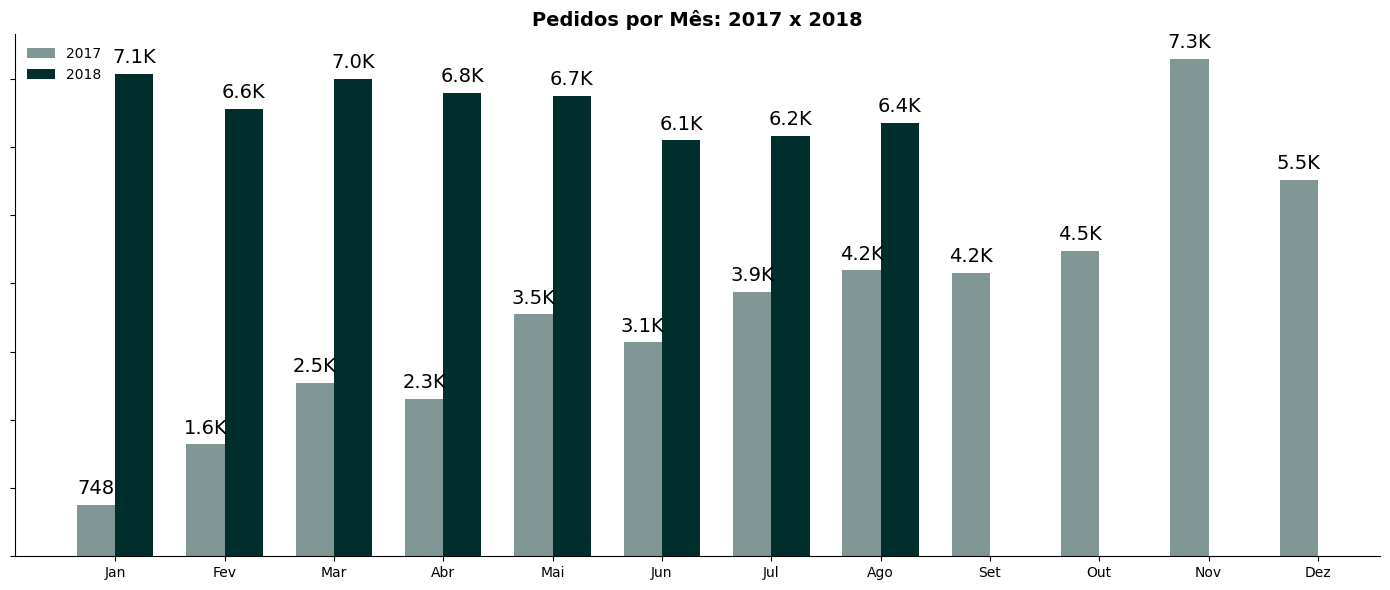

In [ ]:
# GRÁFICO 1: PEDIDOS 2017 x 2018
print("\n📊 Gerando: Pedidos por Mês 2017 x 2018")

fig, ax = plt.subplots(figsize=(14, 6))

x = range(1, 13)
largura = 0.35

bars_2017 = ax.bar([i - largura/2 for i in x if i in dados_2017.index],
                    [dados_2017.loc[i, 'pedidos'] if i in dados_2017.index else 0 for i in x if i in dados_2017.index],
                    largura, label='2017', color=COR_PRINCIPAL, alpha=0.5)

bars_2018 = ax.bar([i + largura/2 for i in x if i in dados_2018.index],
                    [dados_2018.loc[i, 'pedidos'] if i in dados_2018.index else 0 for i in x if i in dados_2018.index],
                    largura, label='2018', color=COR_PRINCIPAL, alpha=1)

for bar in bars_2017:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            fmt_compacto(bar.get_height()), ha='center', va='bottom', fontsize=14, color='black')

for bar in bars_2018:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            fmt_compacto(bar.get_height()), ha='center', va='bottom', fontsize=14, color='black')

ax.set_xticks(x)
ax.set_xticklabels(meses_nome)
ax.set_yticklabels([])
ax.set_title('Pedidos por Mês: 2017 x 2018', fontsize=14, fontweight='bold', color='black')
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
estilo_limpo(ax)
plt.tight_layout()
plt.savefig('grafico_01_pedidos_2017_2018.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


📊 Gerando: Receita por Mês 2017 x 2018


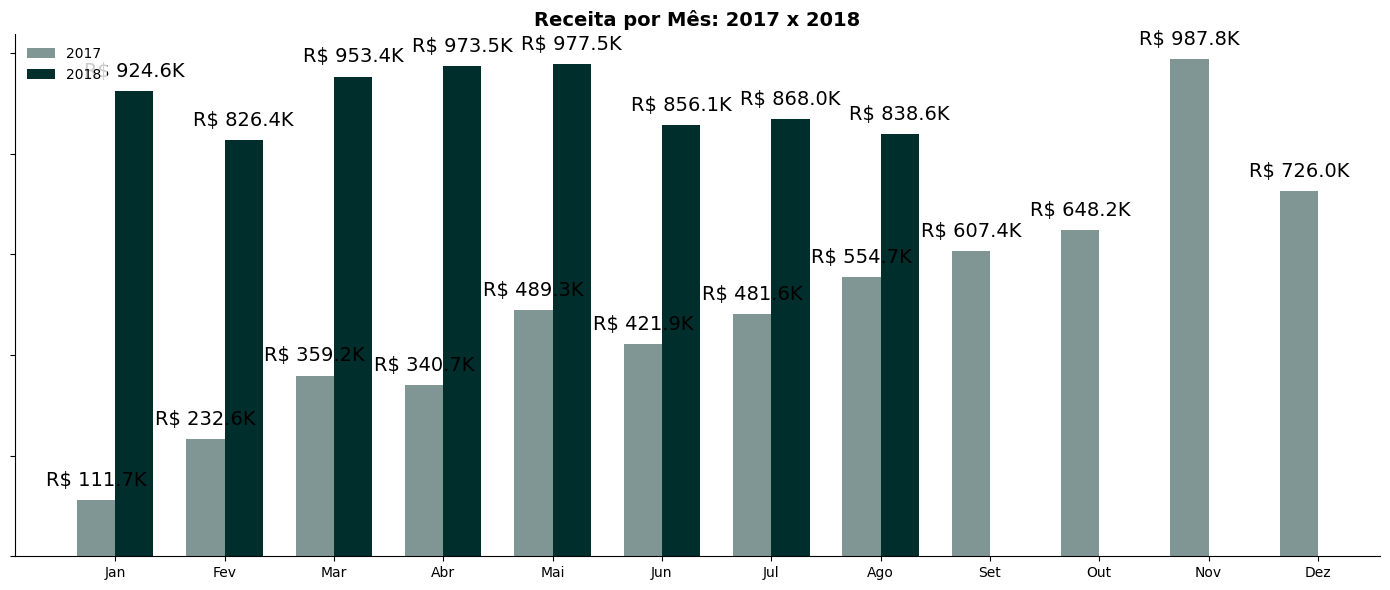

In [ ]:
# GRÁFICO 2: RECEITA 2017 x 2018
print("\n📊 Gerando: Receita por Mês 2017 x 2018")

fig, ax = plt.subplots(figsize=(14, 6))

bars_2017 = ax.bar([i - largura/2 for i in x if i in dados_2017.index],
                    [dados_2017.loc[i, 'receita'] if i in dados_2017.index else 0 for i in x if i in dados_2017.index],
                    largura, label='2017', color=COR_PRINCIPAL, alpha=0.5)

bars_2018 = ax.bar([i + largura/2 for i in x if i in dados_2018.index],
                    [dados_2018.loc[i, 'receita'] if i in dados_2018.index else 0 for i in x if i in dados_2018.index],
                    largura, label='2018', color=COR_PRINCIPAL, alpha=1)

for bar in bars_2017:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20000,
            fmt_compacto_reais(bar.get_height()), ha='center', va='bottom', fontsize=14, color='black')

for bar in bars_2018:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20000,
            fmt_compacto_reais(bar.get_height()), ha='center', va='bottom', fontsize=14, color='black')

ax.set_xticks(x)
ax.set_xticklabels(meses_nome)
ax.set_yticklabels([])
ax.set_title('Receita por Mês: 2017 x 2018', fontsize=14, fontweight='bold', color='black')
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
estilo_limpo(ax)
plt.tight_layout()
plt.savefig('grafico_02_receita_2017_2018.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()



📊 Gerando: Ticket Médio por Mês 2017 x 2018


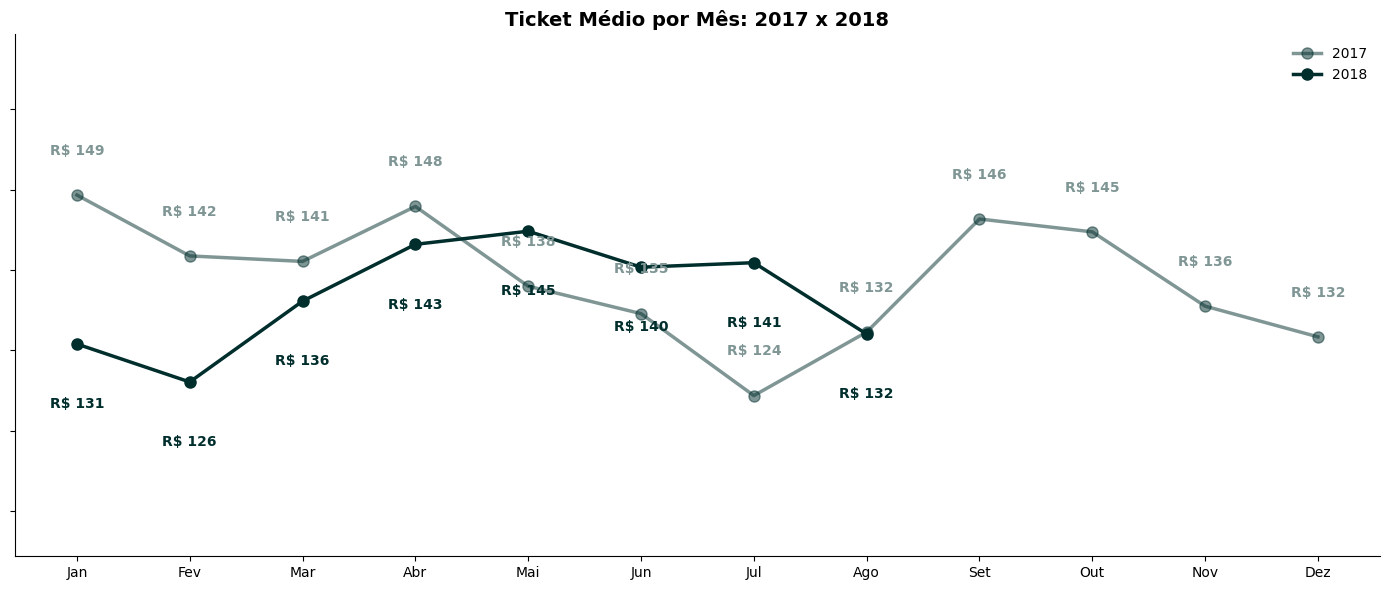

In [ ]:
# GRÁFICO 3: TICKET MÉDIO 2017 x 2018
print("\n📊 Gerando: Ticket Médio por Mês 2017 x 2018")

fig, ax = plt.subplots(figsize=(14, 6))

meses_2017 = [i for i in range(1, 13) if i in dados_2017.index]
valores_2017 = [dados_2017.loc[i, 'ticket_medio'] for i in meses_2017]

meses_2018 = [i for i in range(1, 13) if i in dados_2018.index]
valores_2018 = [dados_2018.loc[i, 'ticket_medio'] for i in meses_2018]

ax.plot(meses_2017, valores_2017, marker='o', linewidth=2.5, color=COR_PRINCIPAL, alpha=0.5, label='2017', markersize=8)
ax.plot(meses_2018, valores_2018, marker='o', linewidth=2.5, color=COR_PRINCIPAL, alpha=1, label='2018', markersize=8)

for i, (mes, valor) in enumerate(zip(meses_2017, valores_2017)):
    # 2017: rótulos SEMPRE acima da linha (verde claro)
    ax.text(mes, valor + 5, f"R$ {valor:.0f}", ha='center', fontsize=10, fontweight='bold', color='#7F9695')

for i, (mes, valor) in enumerate(zip(meses_2018, valores_2018)):
    # 2018: rótulos SEMPRE abaixo da linha (verde escuro)
    ax.text(mes, valor - 8, f"R$ {valor:.0f}", ha='center', fontsize=10, fontweight='bold', color=COR_PRINCIPAL)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses_nome)
ax.set_yticklabels([])
ax.set_ylim(min(valores_2017 + valores_2018) - 20, max(valores_2017 + valores_2018) + 20)
ax.set_title('Ticket Médio por Mês: 2017 x 2018', fontsize=14, fontweight='bold', color='black')
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
estilo_limpo(ax)
plt.tight_layout()
plt.savefig('grafico_03_ticket_medio_2017_2018.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


📊 Gerando: Top 15 Categorias por Receita


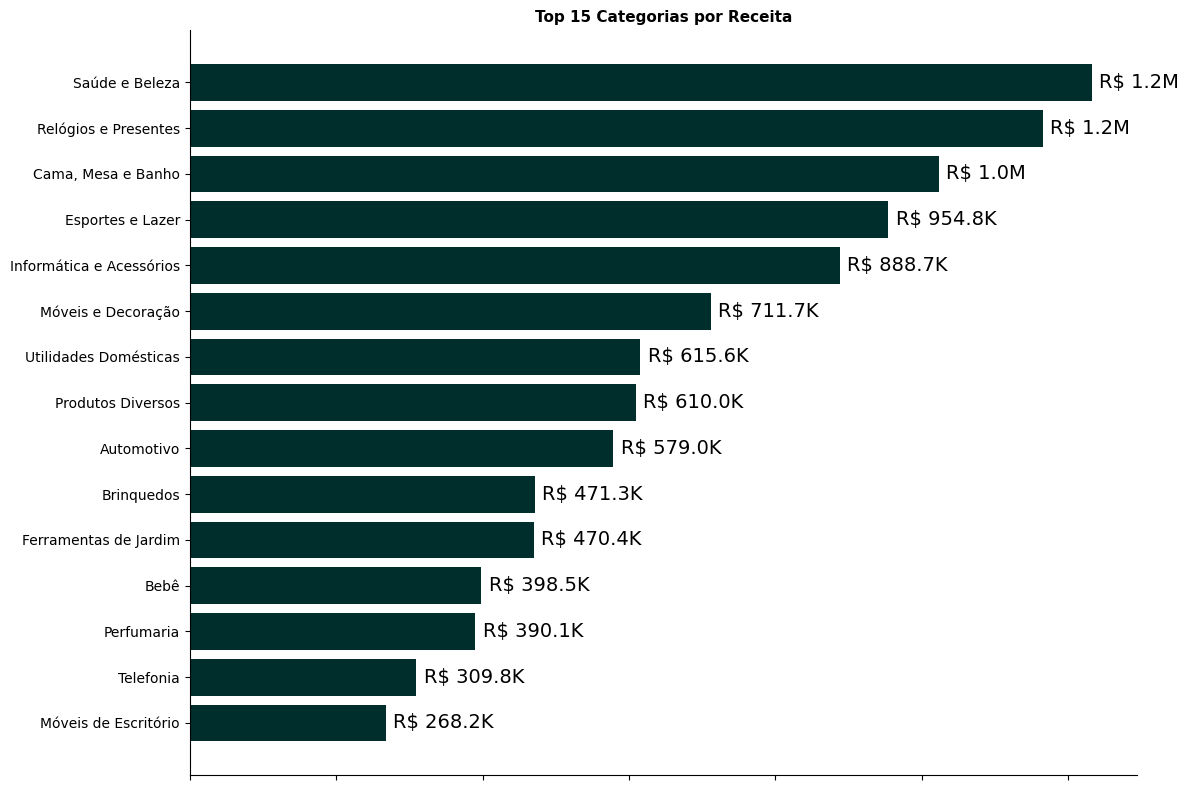

In [ ]:
# GRÁFICO 4: TOP 15 CATEGORIAS POR RECEITA
print("\n📊 Gerando: Top 15 Categorias por Receita")

# Dicionário de tradução inglês -> português
en_to_pt = {
    'health_beauty': 'Saúde e Beleza',
    'watches_gifts': 'Relógios e Presentes',
    'bed_bath_table': 'Cama, Mesa e Banho',
    'sports_leisure': 'Esportes e Lazer',
    'computers_accessories': 'Informática e Acessórios',
    'furniture_decor': 'Móveis e Decoração',
    'housewares': 'Utilidades Domésticas',
    'auto': 'Automotivo',
    'garden_tools': 'Ferramentas de Jardim',
    'cool_stuff': 'Produtos Diversos',
    'perfumery': 'Perfumaria',
    'toys': 'Brinquedos',
    'telephony': 'Telefonia',
    'stationery': 'Papelaria',
    'fashion_bags_accessories': 'Bolsas e Acessórios',
    'electronics': 'Eletrônicos',
    'baby': 'Bebê',
    'office_furniture': 'Móveis de Escritório',
    'computers': 'Computadores',
    'musical_instruments': 'Instrumentos Musicais',
    'consoles_games': 'Consoles e Games',
    'small_appliances': 'Pequenos Eletrodomésticos',
    'home_appliances': 'Eletrodomésticos',
    'pet_shop': 'Pet Shop',
    'fashion_shoes': 'Calçados',
    'books_general_interest': 'Livros',
    'food_drink': 'Alimentos e Bebidas',
    'construction_tools_construction': 'Ferramentas Construção',
    'luggage_accessories': 'Malas e Acessórios',
    'signaling_and_security': 'Sinalização e Segurança',
    'cine_photo': 'Cinema e Foto',
    'la_cuisine': 'Cozinha Gourmet',
    'home_confort': 'Conforto Casa',
    'audio': 'Áudio',
    'market_place': 'Marketplace',
    'construction_tools_lights': 'Iluminação',
    'costruction_tools_tools': 'Ferramentas',
    'fashion_male_clothing': 'Moda Masculina',
    'fashion_female_clothing': 'Moda Feminina',
    'fashion_childrens_clothes': 'Moda Infantil',
    'fashion_underwear_beach': 'Moda Íntima e Praia',
    'fashion_sport': 'Moda Esportiva',
    'diapers_and_hygiene': 'Fraldas e Higiene',
    'flowers': 'Flores',
    'christmas_supplies': 'Artigos de Natal',
    'party_supplies': 'Artigos para Festa',
    'arts_and_craftmanship': 'Artes e Artesanato',
    'drinks': 'Bebidas',
    'food': 'Alimentos',
    'books_technical': 'Livros Técnicos',
    'books_imported': 'Livros Importados',
    'dvds_blu_ray': 'DVDs e Blu-Ray',
    'music': 'Música',
    'tablets_printing_image': 'Tablets e Impressão',
    'fixed_telephony': 'Telefonia Fixa',
    'air_conditioning': 'Ar Condicionado',
    'furniture_living_room': 'Móveis Sala',
    'furniture_bedroom': 'Móveis Quarto',
    'furniture_mattress_and_upholstery': 'Colchões',
    'kitchen_dining_laundry_garden_furniture': 'Móveis Cozinha/Jardim',
    'home_construction': 'Construção Residencial',
    'agro_industry_and_commerce': 'Agronegócio',
    'industry_commerce_and_business': 'Indústria e Comércio',
    'security_and_services': 'Segurança e Serviços',
    'sem_categoria': 'Sem Categoria'
}

receita_cat = vendas_categoria.groupby('categoria').agg(
    receita=('price', 'sum')
).sort_values('receita', ascending=True).tail(15)

# Traduzir categorias para português
receita_cat_pt = receita_cat.copy()
receita_cat_pt.index = receita_cat_pt.index.map(lambda x: en_to_pt.get(x, x.replace('_', ' ').title()))

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(receita_cat_pt.index, receita_cat_pt['receita'], color=COR_PRINCIPAL)

for bar in bars:
    ax.text(bar.get_width() + 10000, bar.get_y() + bar.get_height()/2,
            fmt_compacto_reais(bar.get_width()), va='center', fontsize=14, color='black')

ax.set_xticklabels([])
ax.tick_params(axis='y', labelsize=10)
ax.set_title('Top 15 Categorias por Receita', fontsize=11, fontweight='bold', color='black')
estilo_limpo(ax)
plt.tight_layout()
plt.savefig('grafico_04_top15_categorias.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


📊 Gerando: Top 10 Estados por Receita


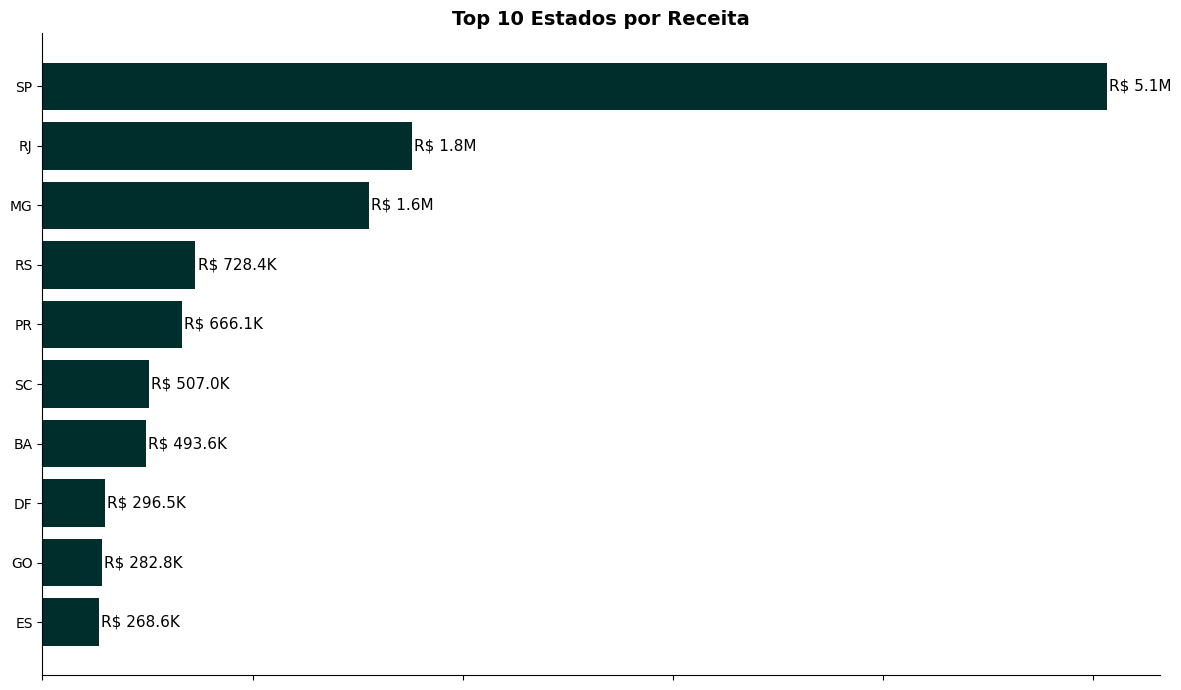

In [ ]:
# GRÁFICO 5: TOP 10 ESTADOS POR RECEITA
print("\n📊 Gerando: Top 10 Estados por Receita")

vendas_uf = vendas.merge(orders_clean[['order_id', 'customer_id']], on='order_id')
vendas_uf = vendas_uf.merge(customers[['customer_id', 'customer_state']], on='customer_id')

receita_uf = vendas_uf.groupby('customer_state').agg(
    receita=('price', 'sum')
).sort_values('receita', ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(receita_uf.index, receita_uf['receita'], color=COR_PRINCIPAL)

for bar in bars:
    ax.text(bar.get_width() + 10000, bar.get_y() + bar.get_height()/2,
            fmt_compacto_reais(bar.get_width()), va='center', fontsize=11, color='black')

ax.set_xticklabels([])
ax.set_title('Top 10 Estados por Receita', fontsize=14, fontweight='bold', color='black')
estilo_limpo(ax)
plt.tight_layout()
plt.savefig('grafico_05_top10_estados.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


📊 Gerando: Top 10 Municípios por Receita


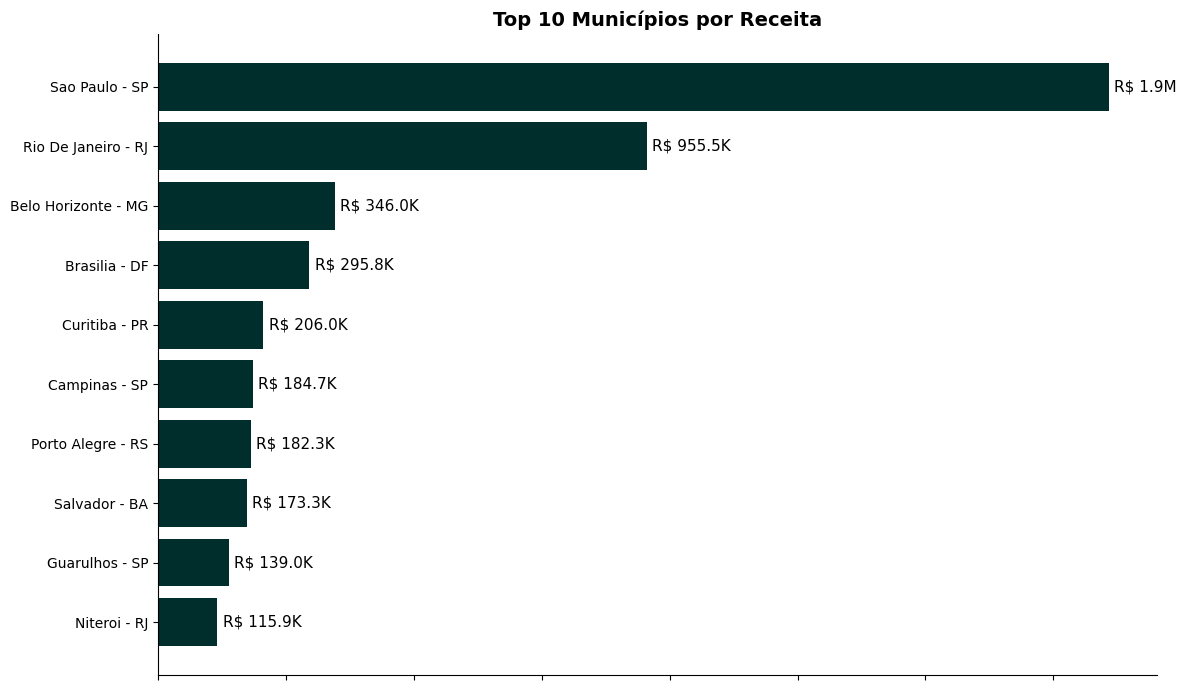

In [ ]:
# GRÁFICO 6: TOP 10 MUNICÍPIOS POR RECEITA
print("\n📊 Gerando: Top 10 Municípios por Receita")

vendas_cidade = vendas.merge(orders_clean[['order_id', 'customer_id']], on='order_id')
vendas_cidade = vendas_cidade.merge(customers[['customer_id', 'customer_city', 'customer_state']], on='customer_id')
vendas_cidade['cidade_uf'] = vendas_cidade['customer_city'].str.title() + ' - ' + vendas_cidade['customer_state']

receita_cidade = vendas_cidade.groupby('cidade_uf').agg(
    receita=('price', 'sum')
).sort_values('receita', ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(receita_cidade.index, receita_cidade['receita'], color=COR_PRINCIPAL)

for bar in bars:
    ax.text(bar.get_width() + 10000, bar.get_y() + bar.get_height()/2,
            fmt_compacto_reais(bar.get_width()), va='center', fontsize=11, color='black')

ax.set_xticklabels([])
ax.set_title('Top 10 Municípios por Receita', fontsize=14, fontweight='bold', color='black')
estilo_limpo(ax)
plt.tight_layout()
plt.savefig('grafico_06_top10_municipios.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


📊 Gerando: Receita por Unidade Vendida - Top 15 Categorias


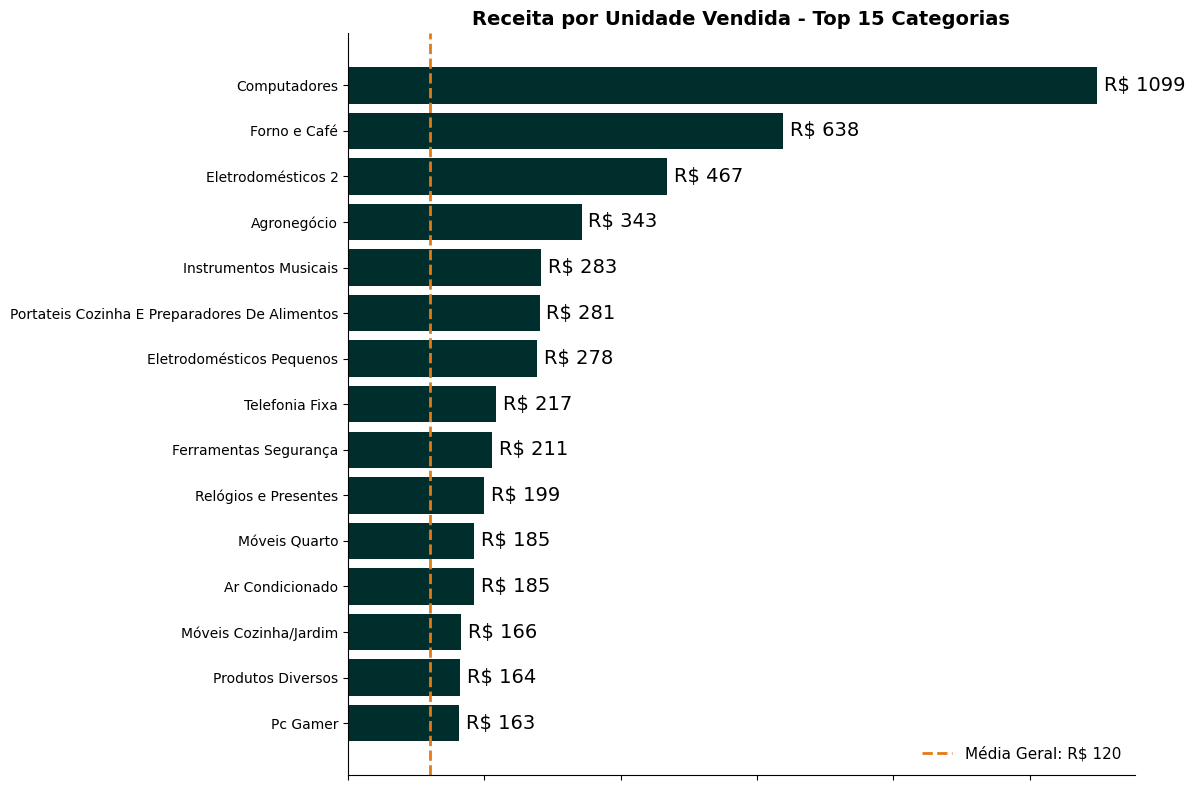

In [ ]:
# GRÁFICO 9: RECEITA POR UNIDADE - TOP 15 CATEGORIAS
print("\n📊 Gerando: Receita por Unidade Vendida - Top 15 Categorias")

# Criar dicionário de tradução a partir do category_translation
traducao_dict = dict(zip(category_translation['product_category_name'],
                         category_translation['product_category_name_english']))

# Dicionário adicional para traduzir do inglês para português
en_to_pt = {
    'health_beauty': 'Saúde e Beleza',
    'watches_gifts': 'Relógios e Presentes',
    'bed_bath_table': 'Cama, Mesa e Banho',
    'sports_leisure': 'Esportes e Lazer',
    'computers_accessories': 'Informática e Acessórios',
    'furniture_decor': 'Móveis e Decoração',
    'housewares': 'Utilidades Domésticas',
    'auto': 'Automotivo',
    'garden_tools': 'Ferramentas Jardim',
    'cool_stuff': 'Produtos Diversos',
    'perfumery': 'Perfumaria',
    'toys': 'Brinquedos',
    'telephony': 'Telefonia',
    'stationery': 'Papelaria',
    'fashion_bags_accessories': 'Bolsas e Acessórios',
    'electronics': 'Eletrônicos',
    'baby': 'Bebê',
    'construction_tools_construction': 'Ferramentas Construção',
    'office_furniture': 'Móveis Escritório',
    'computers': 'Computadores',
    'musical_instruments': 'Instrumentos Musicais',
    'consoles_games': 'Consoles e Games',
    'air_conditioning': 'Ar Condicionado',
    'small_appliances': 'Eletrodomésticos Pequenos',
    'home_appliances': 'Eletrodomésticos',
    'home_appliances_2': 'Eletrodomésticos 2',
    'luggage_accessories': 'Malas e Acessórios',
    'signaling_and_security': 'Sinalização e Segurança',
    'pet_shop': 'Pet Shop',
    'fashion_shoes': 'Calçados',
    'fashion_male_clothing': 'Moda Masculina',
    'fashion_underwear_beach': 'Moda Íntima e Praia',
    'fashion_sport': 'Moda Esportiva',
    'books_general_interest': 'Livros',
    'books_technical': 'Livros Técnicos',
    'food_drink': 'Alimentos e Bebidas',
    'food': 'Alimentos',
    'drinks': 'Bebidas',
    'market_place': 'Marketplace',
    'fixed_telephony': 'Telefonia Fixa',
    'tablets_printing_image': 'Tablets e Impressão',
    'audio': 'Áudio',
    'dvds_blu_ray': 'DVDs e Blu-Ray',
    'music': 'Música',
    'flowers': 'Flores',
    'christmas_supplies': 'Artigos de Natal',
    'party_supplies': 'Artigos para Festa',
    'arts_and_craftmanship': 'Artes e Artesanato',
    'la_cuisine': 'Cozinha',
    'fashion_childrens_clothes': 'Moda Infantil',
    'fashion_female_clothing': 'Moda Feminina',
    'diapers_and_hygiene': 'Fraldas e Higiene',
    'home_confort': 'Conforto Casa',
    'home_comfort_2': 'Conforto Casa 2',
    'furniture_living_room': 'Móveis Sala',
    'furniture_bedroom': 'Móveis Quarto',
    'furniture_mattress_and_upholstery': 'Colchões e Estofados',
    'cine_photo': 'Cinema e Foto',
    'construction_tools_lights': 'Iluminação',
    'construction_tools_safety': 'Ferramentas Segurança',
    'home_construction': 'Construção Residencial',
    'sem_categoria': 'Sem Categoria',
    'costruction_tools_tools': 'Ferramentas',
    'security_and_services': 'Segurança e Serviços',
    'industry_commerce_and_business': 'Indústria e Comércio',
    'agro_industry_and_commerce': 'Agronegócio',
    'kitchen_dining_laundry_garden_furniture': 'Móveis Cozinha/Jardim',
    'portable_kitchen_food_processors': 'Processadores Alimentos',
    'small_appliances_home_oven_and_coffee': 'Forno e Café',
    'books_imported': 'Livros Importados',
    'cds_dvds_musicals': 'CDs e DVDs'
}

receita_por_unidade = receita_total / unidades_vendidas

receita_unidade_cat = vendas_categoria.groupby('categoria').agg(
    receita=('price', 'sum'),
    unidades=('price', 'count')
).reset_index()
receita_unidade_cat['receita_por_unidade'] = receita_unidade_cat['receita'] / receita_unidade_cat['unidades']
receita_unidade_cat = receita_unidade_cat.sort_values('receita_por_unidade', ascending=True).tail(15)

# Traduzir categorias para português
receita_unidade_cat['categoria_pt'] = receita_unidade_cat['categoria'].map(en_to_pt).fillna(receita_unidade_cat['categoria'].str.replace('_', ' ').str.title())

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(receita_unidade_cat['categoria_pt'], receita_unidade_cat['receita_por_unidade'], color=COR_PRINCIPAL)

for bar in bars:
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f"R$ {bar.get_width():.0f}", va='center', fontsize=14, color='black')

ax.axvline(x=receita_por_unidade, color=COR_DESTAQUE, linestyle='--', linewidth=2,
           label=f'Média Geral: R$ {receita_por_unidade:.0f}')
ax.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none', fontsize=11)

ax.set_xticklabels([])
ax.tick_params(axis='y', labelsize=10)
ax.set_title('Receita por Unidade Vendida - Top 15 Categorias', fontsize=14, fontweight='bold', color='black')
estilo_limpo(ax)
plt.tight_layout()
plt.savefig('grafico_09_receita_unidade_categoria.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


📊 Gerando: Receita por Unidade Vendida - Por Estado


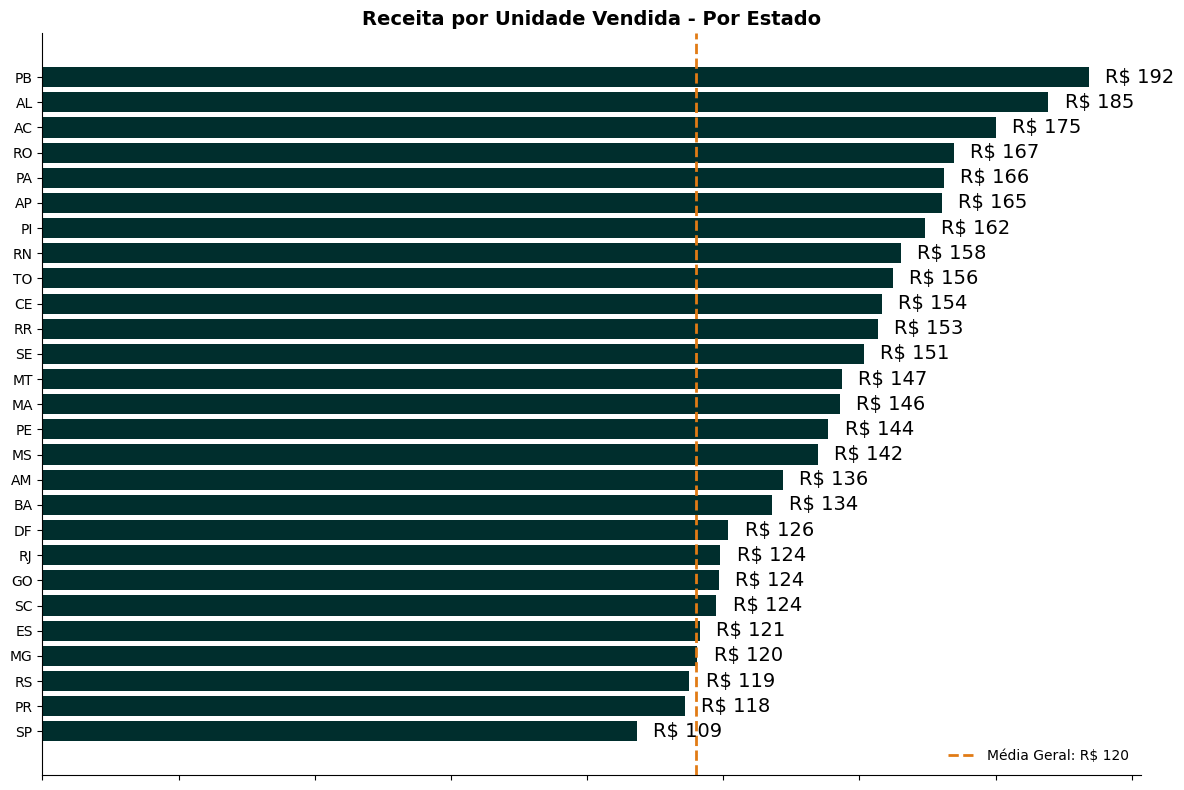

In [ ]:
# GRÁFICO 10: RECEITA POR UNIDADE - POR ESTADO
print("\n📊 Gerando: Receita por Unidade Vendida - Por Estado")

receita_unidade_uf = vendas_uf.groupby('customer_state').agg(
    receita=('price', 'sum'),
    unidades=('price', 'count')
).reset_index()
receita_unidade_uf['receita_por_unidade'] = receita_unidade_uf['receita'] / receita_unidade_uf['unidades']
receita_unidade_uf = receita_unidade_uf.sort_values('receita_por_unidade', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(receita_unidade_uf['customer_state'], receita_unidade_uf['receita_por_unidade'], color=COR_PRINCIPAL)

for bar in bars:
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f"R$ {bar.get_width():.0f}", va='center', fontsize=14, color='black')

ax.axvline(x=receita_por_unidade, color=COR_DESTAQUE, linestyle='--', linewidth=2,
           label=f'Média Geral: R$ {receita_por_unidade:.0f}')
ax.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none')

ax.set_xticklabels([])
ax.set_title('Receita por Unidade Vendida - Por Estado', fontsize=14, fontweight='bold', color='black')
estilo_limpo(ax)
plt.tight_layout()
plt.savefig('grafico_10_receita_unidade_estado.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


📊 Gerando: Lead Time Total (Compra → Entrega)


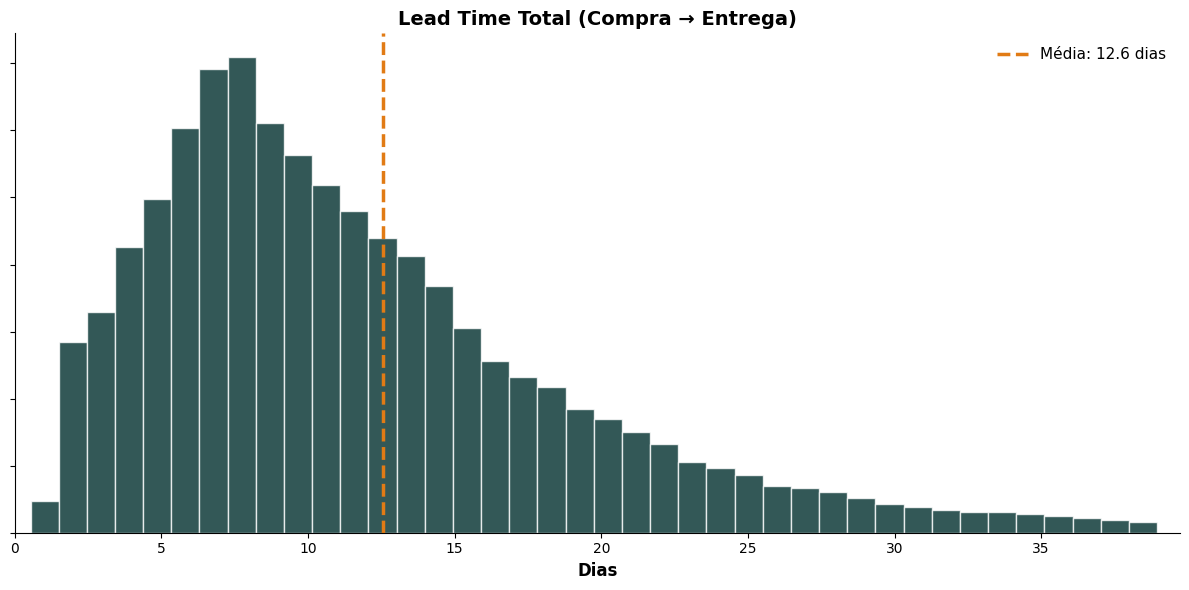

In [ ]:
# GRÁFICO 12: LEAD TIME TOTAL
print("\n📊 Gerando: Lead Time Total (Compra → Entrega)")

fig, ax = plt.subplots(figsize=(12, 6))

data = orders_delivered['lead_time_total'].dropna()
# Filtrar outliers para melhor visualização (percentil 98)
limite_sup = data.quantile(0.98)
data_filtrado = data[data <= limite_sup]
n, bins, patches = ax.hist(data_filtrado, bins=40, color=COR_PRINCIPAL, alpha=0.8, edgecolor='white')

# Linha de média (usando dados originais)
media = data.mean()
ax.axvline(media, color=COR_DESTAQUE, linestyle='--', linewidth=2.5,
           label=f'Média: {media:.1f} dias')

# Ajustar eixo X para ficar próximo dos dados
ax.set_xlim(0, limite_sup * 1.02)

ax.set_xlabel('Dias', fontsize=12, fontweight='bold')
ax.set_yticklabels([])
ax.set_title('Lead Time Total (Compra → Entrega)', fontsize=14, fontweight='bold', color='black')
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none', fontsize=11)
estilo_limpo(ax)
plt.tight_layout()
plt.savefig('grafico_12_lead_time_total.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


📊 Gerando: Lead Time Aprovação (Compra → Aprovação)


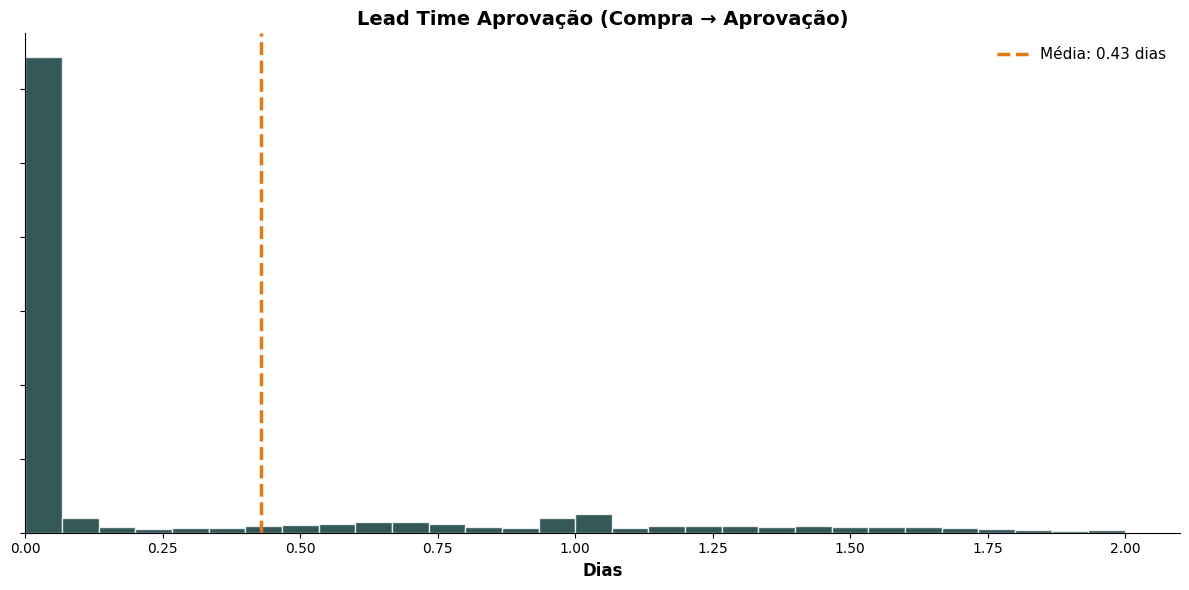

In [ ]:
# GRÁFICO 13: LEAD TIME APROVAÇÃO
print("\n📊 Gerando: Lead Time Aprovação (Compra → Aprovação)")

fig, ax = plt.subplots(figsize=(12, 6))

data = orders_delivered['lead_time_aprovacao'].dropna()
data = data[data <= 2]  # Filtrar outliers para melhor visualização

n, bins, patches = ax.hist(data, bins=30, color=COR_PRINCIPAL, alpha=0.8, edgecolor='white')

media = orders_delivered['lead_time_aprovacao'].mean()
ax.axvline(media, color=COR_DESTAQUE, linestyle='--', linewidth=2.5,
           label=f'Média: {media:.2f} dias')

# Ajustar eixo X próximo aos dados
ax.set_xlim(0, data.max() * 1.05)

ax.set_xlabel('Dias', fontsize=12, fontweight='bold')
ax.set_yticklabels([])
ax.set_title('Lead Time Aprovação (Compra → Aprovação)', fontsize=14, fontweight='bold', color='black')
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none', fontsize=11)
estilo_limpo(ax)
plt.tight_layout()
plt.savefig('grafico_13_lead_time_aprovacao.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()



📊 Gerando: Lead Time Postagem (Aprovação → Envio)


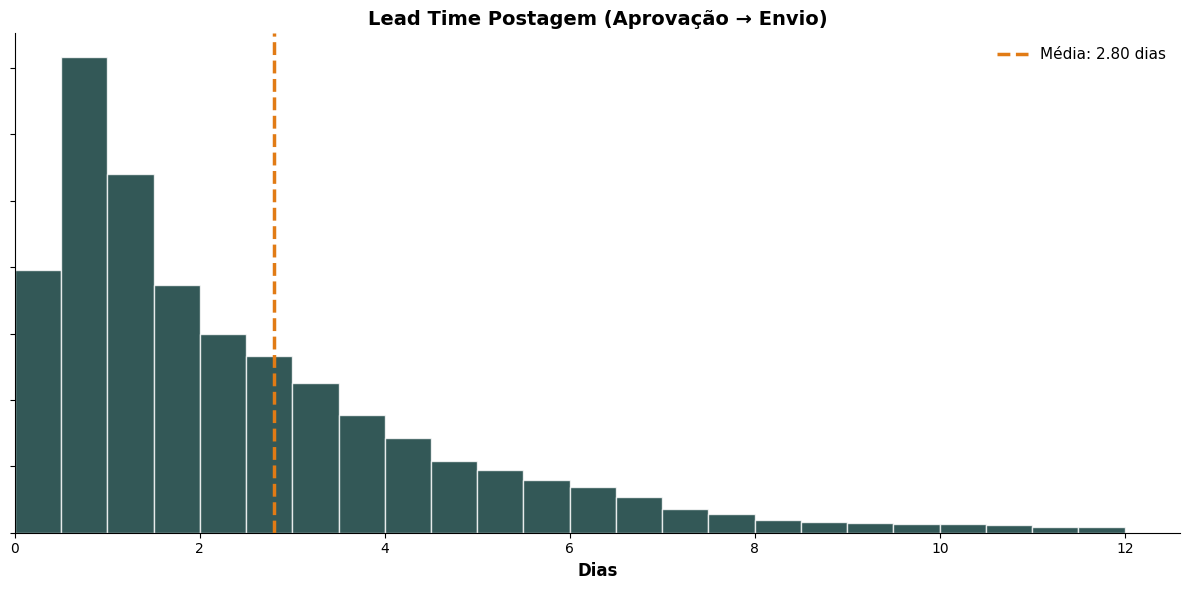

In [ ]:
# GRÁFICO 14: LEAD TIME POSTAGEM
print("\n📊 Gerando: Lead Time Postagem (Aprovação → Envio)")

fig, ax = plt.subplots(figsize=(12, 6))

data = orders_delivered['lead_time_postagem'].dropna()
data = data[(data >= 0) & (data <= 12)]  # Filtrar outliers

n, bins, patches = ax.hist(data, bins=24, color=COR_PRINCIPAL, alpha=0.8, edgecolor='white')

media = orders_delivered['lead_time_postagem'].mean()
ax.axvline(media, color=COR_DESTAQUE, linestyle='--', linewidth=2.5,
           label=f'Média: {media:.2f} dias')

# Ajustar eixo X próximo aos dados
ax.set_xlim(0, data.max() * 1.05)

ax.set_xlabel('Dias', fontsize=12, fontweight='bold')
ax.set_yticklabels([])
ax.set_title('Lead Time Postagem (Aprovação → Envio)', fontsize=14, fontweight='bold', color='black')
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none', fontsize=11)
estilo_limpo(ax)
plt.tight_layout()
plt.savefig('grafico_14_lead_time_postagem.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


📊 Gerando: Lead Time Trânsito (Envio → Entrega)


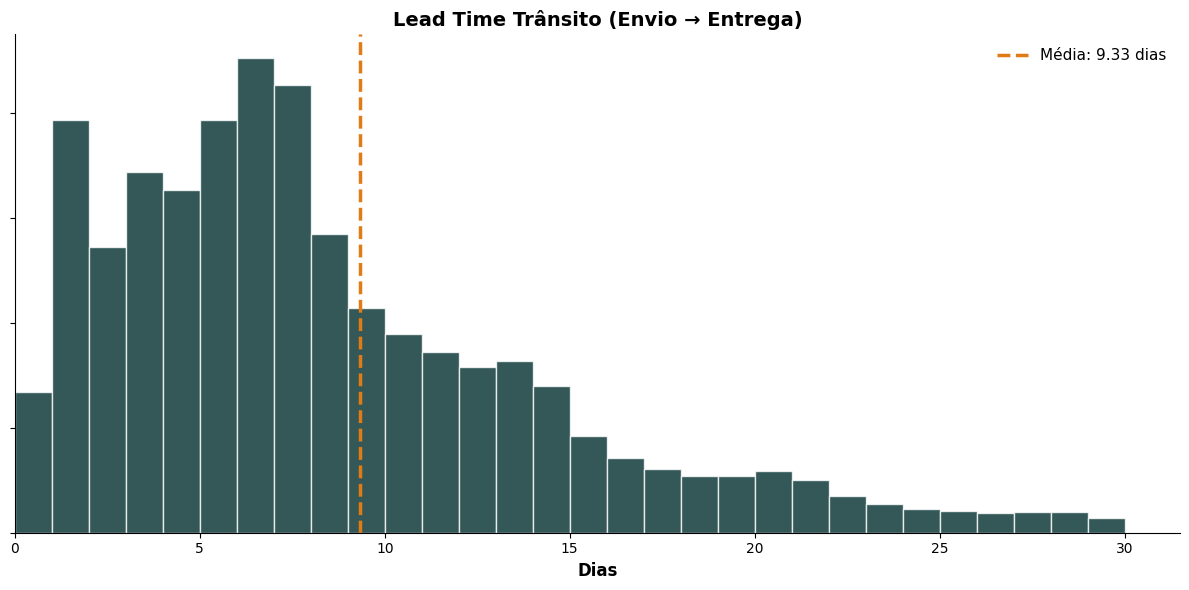

In [ ]:

# GRÁFICO 15: LEAD TIME TRÂNSITO
print("\n📊 Gerando: Lead Time Trânsito (Envio → Entrega)")

fig, ax = plt.subplots(figsize=(12, 6))

data = orders_delivered['lead_time_transito'].dropna()
data = data[(data >= 0) & (data <= 30)]  # Filtrar outliers

n, bins, patches = ax.hist(data, bins=30, color=COR_PRINCIPAL, alpha=0.8, edgecolor='white')

media = orders_delivered['lead_time_transito'].mean()
ax.axvline(media, color=COR_DESTAQUE, linestyle='--', linewidth=2.5,
           label=f'Média: {media:.2f} dias')

# Ajustar eixo X próximo aos dados
ax.set_xlim(0, data.max() * 1.05)

ax.set_xlabel('Dias', fontsize=12, fontweight='bold')
ax.set_yticklabels([])
ax.set_title('Lead Time Trânsito (Envio → Entrega)', fontsize=14, fontweight='bold', color='black')
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none', fontsize=11)
estilo_limpo(ax)
plt.tight_layout()
plt.savefig('grafico_15_lead_time_transito.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


📊 Gerando: Status de Entrega (No Prazo vs Atrasado)


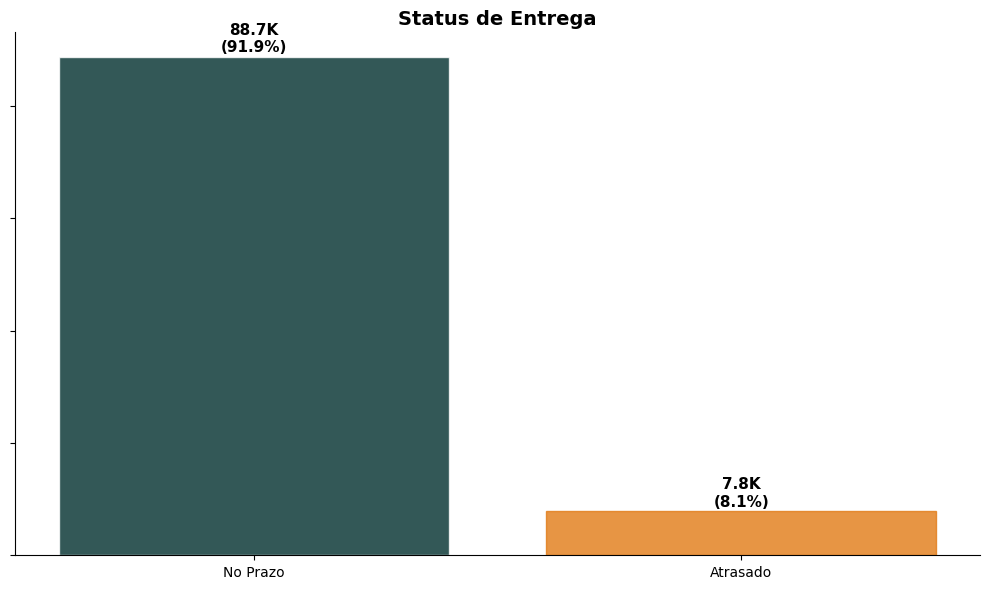

In [ ]:
# GRÁFICO 16: STATUS DE ENTREGA (NO PRAZO vs ATRASADO)
print("\n📊 Gerando: Status de Entrega (No Prazo vs Atrasado)")

fig, ax = plt.subplots(figsize=(10, 6))

status_counts = orders_delivered['status_entrega'].value_counts()

bars = ax.bar(status_counts.index, status_counts.values, color=COR_PRINCIPAL, alpha=0.8, edgecolor='white')

# Cor diferente para atrasado
bars[1].set_color(COR_DESTAQUE) if 'Atrasado' in status_counts.index else None

for bar in bars:
    height = bar.get_height()
    pct = height / status_counts.sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2., height + 500,
            f'{fmt_compacto(height)}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')

ax.set_yticklabels([])
ax.set_title('Status de Entrega', fontsize=14, fontweight='bold', color='black')
estilo_limpo(ax)
plt.tight_layout()
plt.savefig('grafico_16_status_entrega.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


📊 Gerando: Lead Time Médio por Estado


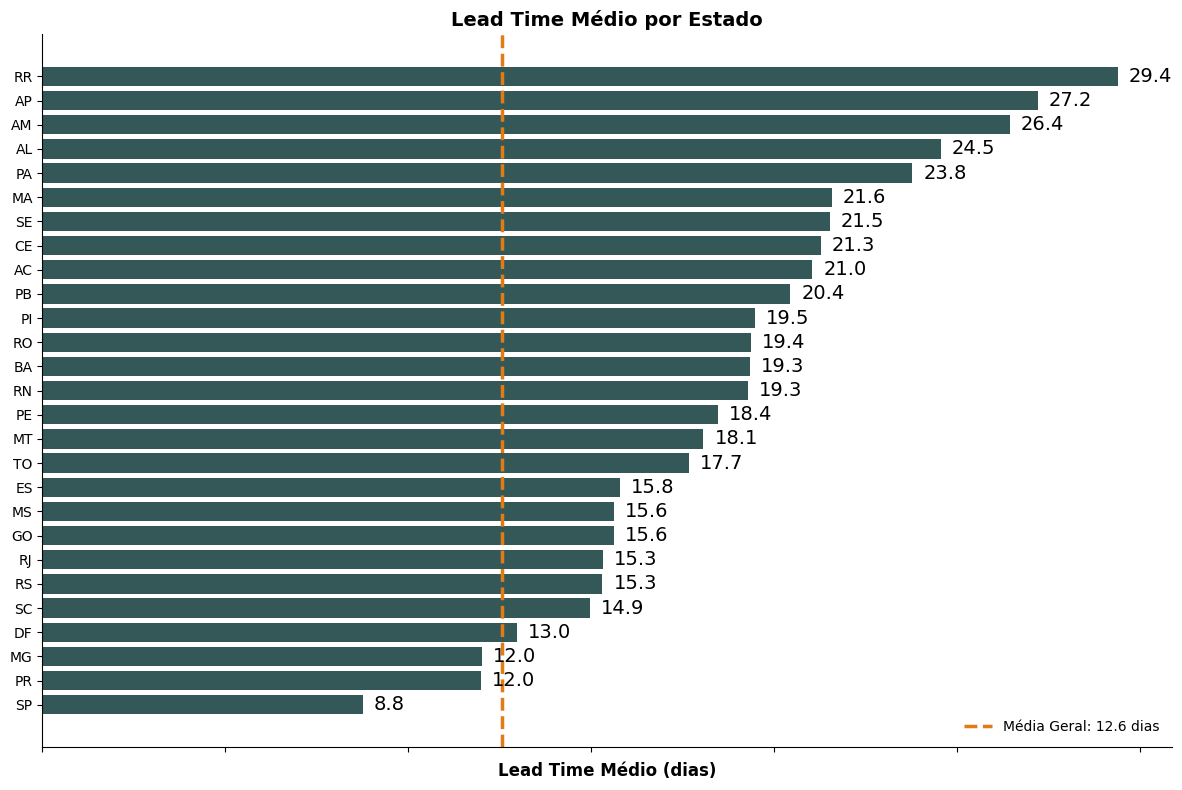

In [ ]:
# GRÁFICO 17: LEAD TIME POR ESTADO (TOP 15)
print("\n📊 Gerando: Lead Time Médio por Estado")

orders_geo = orders_delivered.merge(
    customers[['customer_id', 'customer_state']],
    on='customer_id',
    how='left'
)

geo_stats = orders_geo.groupby('customer_state').agg({
    'order_id': 'count',
    'lead_time_total': 'mean'
}).round(2)
geo_stats.columns = ['Total_Pedidos', 'Lead_Time_Medio']
geo_stats = geo_stats.sort_values('Lead_Time_Medio', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(geo_stats.index, geo_stats['Lead_Time_Medio'], color=COR_PRINCIPAL, alpha=0.8)

# Linha de média geral
media_geral = orders_delivered['lead_time_total'].mean()
ax.axvline(media_geral, color=COR_DESTAQUE, linestyle='--', linewidth=2.5,
           label=f'Média Geral: {media_geral:.1f} dias')

for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}', va='center', fontsize=14, color='black')

ax.set_xticklabels([])
ax.set_xlabel('Lead Time Médio (dias)', fontsize=12, fontweight='bold')
ax.set_title('Lead Time Médio por Estado', fontsize=14, fontweight='bold', color='black')
ax.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none')
estilo_limpo(ax)
plt.tight_layout()
plt.savefig('grafico_17_lead_time_estado.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


📊 Gerando: Evolução Mensal de Pedidos Entregues


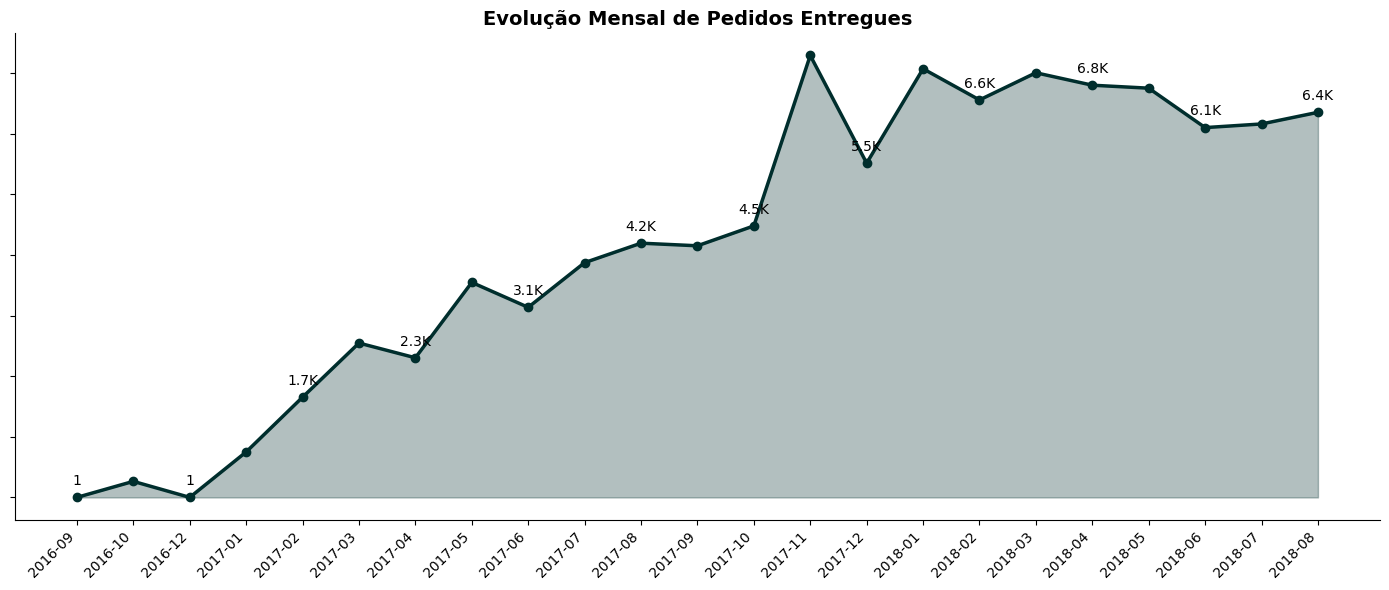

In [ ]:
# GRÁFICO 18: EVOLUÇÃO MENSAL - VOLUME DE PEDIDOS
print("\n📊 Gerando: Evolução Mensal de Pedidos Entregues")

orders_delivered['ano_mes'] = orders_delivered['order_purchase_timestamp'].dt.to_period('M')

monthly = orders_delivered.groupby('ano_mes').agg({
    'order_id': 'count',
    'lead_time_total': 'mean'
}).reset_index()
monthly['ano_mes'] = monthly['ano_mes'].astype(str)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(range(len(monthly)), monthly['order_id'],
        marker='o', linewidth=2.5, markersize=6, color=COR_PRINCIPAL)
ax.fill_between(range(len(monthly)), monthly['order_id'], alpha=0.3, color=COR_PRINCIPAL)

# Rótulos nos pontos (a cada 2 meses para não poluir)
for i, (mes, pedidos) in enumerate(zip(monthly['ano_mes'], monthly['order_id'])):
    if i % 2 == 0:
        ax.text(i, pedidos + 200, fmt_compacto(pedidos), ha='center', fontsize=10, color='black')

ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['ano_mes'], rotation=45, ha='right')
ax.set_yticklabels([])
ax.set_title('Evolução Mensal de Pedidos Entregues', fontsize=14, fontweight='bold', color='black')
estilo_limpo(ax)
plt.tight_layout()
plt.savefig('grafico_18_evolucao_pedidos.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


📊 Gerando: Evolução Mensal do Lead Time


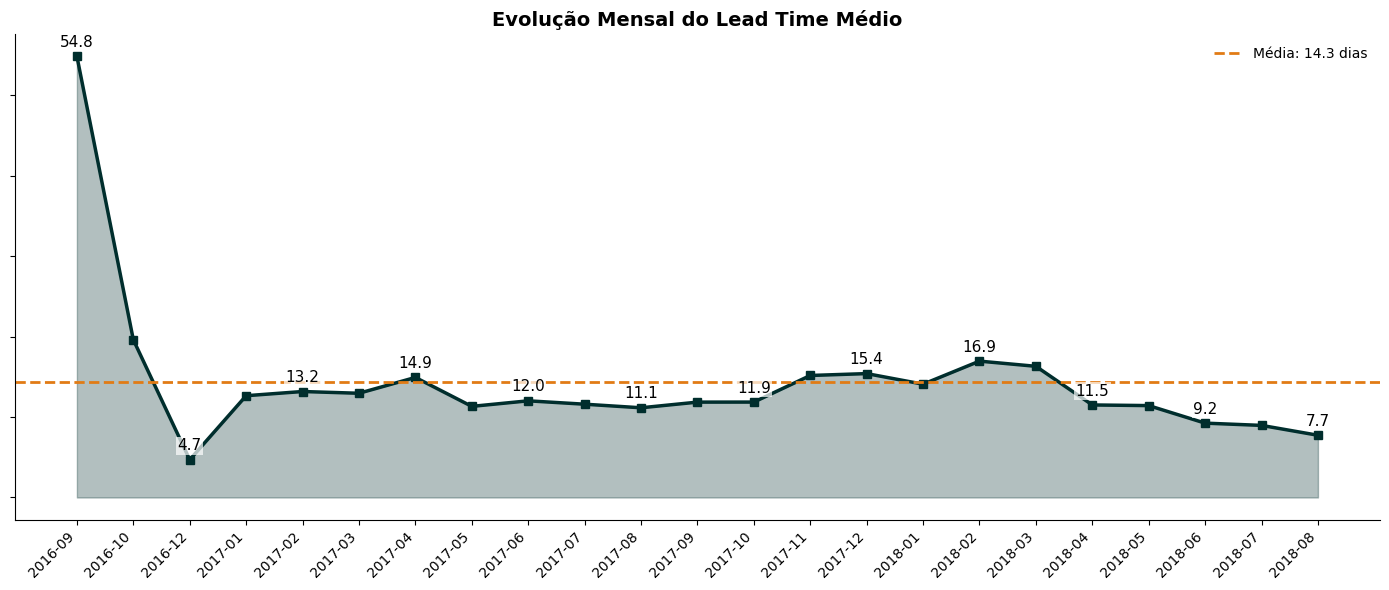

In [ ]:
# GRÁFICO 19: EVOLUÇÃO MENSAL - LEAD TIME
print("\n📊 Gerando: Evolução Mensal do Lead Time")

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(range(len(monthly)), monthly['lead_time_total'],
        marker='s', linewidth=2.5, markersize=6, color=COR_PRINCIPAL)
ax.fill_between(range(len(monthly)), monthly['lead_time_total'], alpha=0.3, color=COR_PRINCIPAL)

# Linha de média
media = monthly['lead_time_total'].mean()
ax.axhline(media, color=COR_DESTAQUE, linestyle='--', linewidth=2,
           label=f'Média: {media:.1f} dias')

# Rótulos nos pontos
for i, (mes, lt) in enumerate(zip(monthly['ano_mes'], monthly['lead_time_total'])):
    if i % 2 == 0:
        ax.text(i, lt + 0.8, f'{lt:.1f}',
        ha='center', va='bottom',
        fontsize=11,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['ano_mes'], rotation=45, ha='right')
ax.set_yticklabels([])
ax.set_title('Evolução Mensal do Lead Time Médio', fontsize=14, fontweight='bold', color='black')
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
estilo_limpo(ax)
plt.tight_layout()
plt.savefig('grafico_19_evolucao_lead_time.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


📊 Gerando: Review Score - No Prazo vs Atrasado


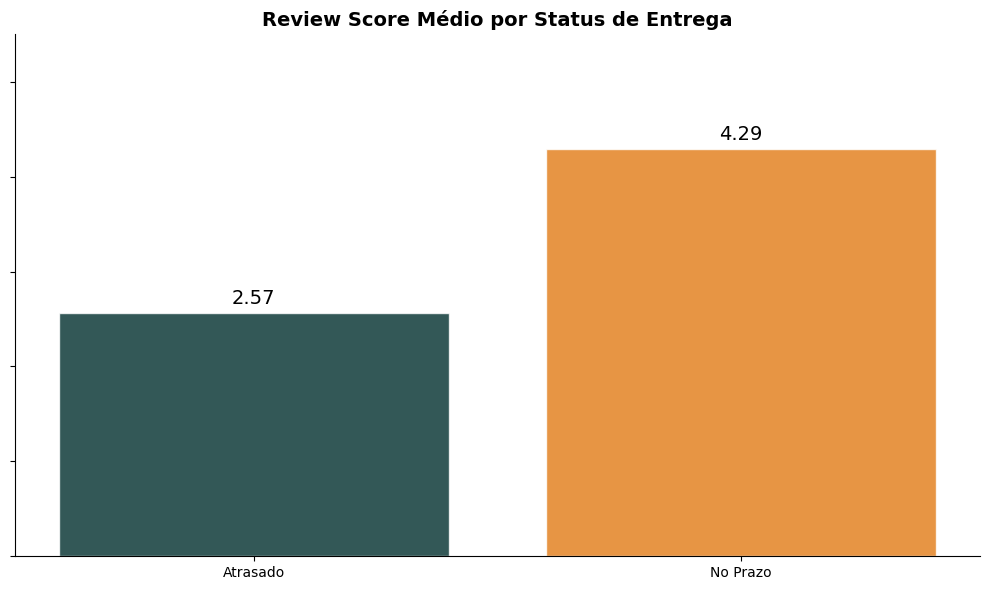

In [ ]:
# GRÁFICO 20: REVIEW SCORE - NO PRAZO vs ATRASADO
print("\n📊 Gerando: Review Score - No Prazo vs Atrasado")

fig, ax = plt.subplots(figsize=(10, 6))

review_by_status = orders_reviews.groupby('status_entrega')['review_score'].mean()

bars = ax.bar(review_by_status.index, review_by_status.values,
              color=[COR_PRINCIPAL, COR_DESTAQUE], alpha=0.8, edgecolor='white')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.05,
            f'{height:.2f}',
            ha='center', va='bottom', fontsize=14, color='black')

ax.set_ylim(0, 5.5)
ax.set_yticklabels([])
ax.set_title('Review Score Médio por Status de Entrega', fontsize=14, fontweight='bold', color='black')
estilo_limpo(ax)
plt.tight_layout()
plt.savefig('grafico_20_review_status.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


📊 Gerando: Distribuição de Review Scores


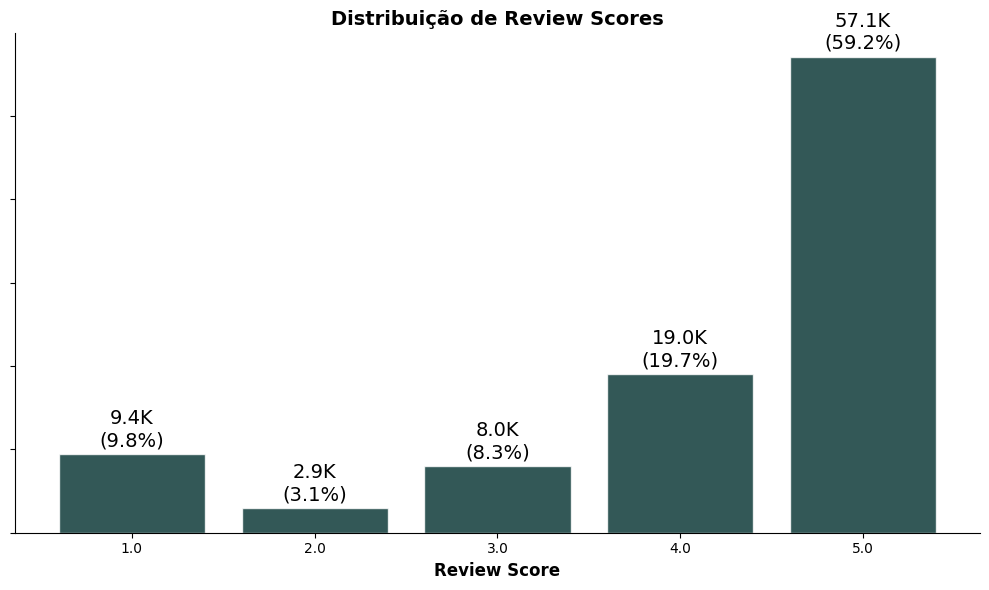

In [ ]:
# GRÁFICO 21: DISTRIBUIÇÃO DE REVIEW SCORES
print("\n📊 Gerando: Distribuição de Review Scores")

fig, ax = plt.subplots(figsize=(10, 6))

review_dist = orders_reviews['review_score'].value_counts().sort_index()

bars = ax.bar(review_dist.index.astype(str), review_dist.values,
              color=COR_PRINCIPAL, alpha=0.8, edgecolor='white')

for bar in bars:
    height = bar.get_height()
    pct = height / review_dist.sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2., height + 500,
            f'{fmt_compacto(height)}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=14, color='black')

ax.set_xlabel('Review Score', fontsize=12, fontweight='bold')
ax.set_yticklabels([])
ax.set_title('Distribuição de Review Scores', fontsize=14, fontweight='bold', color='black')
estilo_limpo(ax)
plt.tight_layout()
plt.savefig('grafico_21_distribuicao_reviews.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


📊 Gerando: Review Score por Faixa de Atraso


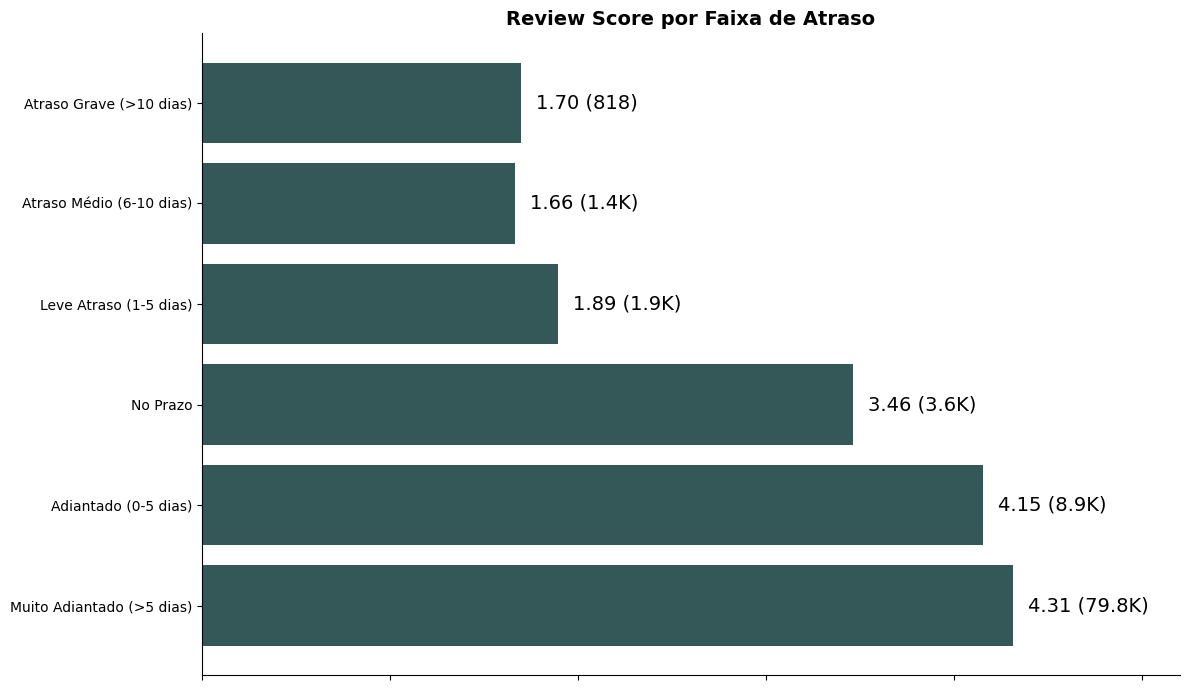

In [ ]:
# GRÁFICO 22: REVIEW SCORE POR FAIXA DE ATRASO
print("\n📊 Gerando: Review Score por Faixa de Atraso")

orders_reviews['faixa_atraso'] = pd.cut(
    orders_reviews['atraso_dias'],
    bins=[-100, -5, 0, 5, 10, 20, 100],
    labels=['Muito Adiantado (>5 dias)', 'Adiantado (0-5 dias)',
            'No Prazo', 'Leve Atraso (1-5 dias)',
            'Atraso Médio (6-10 dias)', 'Atraso Grave (>10 dias)']
)

faixa_review = orders_reviews.groupby('faixa_atraso')['review_score'].agg(['mean', 'count'])
faixa_review = faixa_review[faixa_review['count'] > 100]

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(range(len(faixa_review)), faixa_review['mean'], color=COR_PRINCIPAL, alpha=0.8)

ax.set_yticks(range(len(faixa_review)))
ax.set_yticklabels(faixa_review.index, fontsize=10)

for i, (mean, count) in enumerate(zip(faixa_review['mean'], faixa_review['count'])):
    # Formato limpo: nota e quantidade entre parênteses, sem emoji
    ax.text(mean + 0.08, i, f'{mean:.2f} ({fmt_compacto(count)})',
            va='center', fontsize=14, color='black')

ax.set_xlim(0, 5.2)
ax.set_xticklabels([])
ax.set_title('Review Score por Faixa de Atraso', fontsize=14, fontweight='bold', color='black')
estilo_limpo(ax)
plt.tight_layout()
plt.savefig('grafico_22_review_faixa_atraso.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


📊 Gerando: Distribuição de Meios de Pagamento


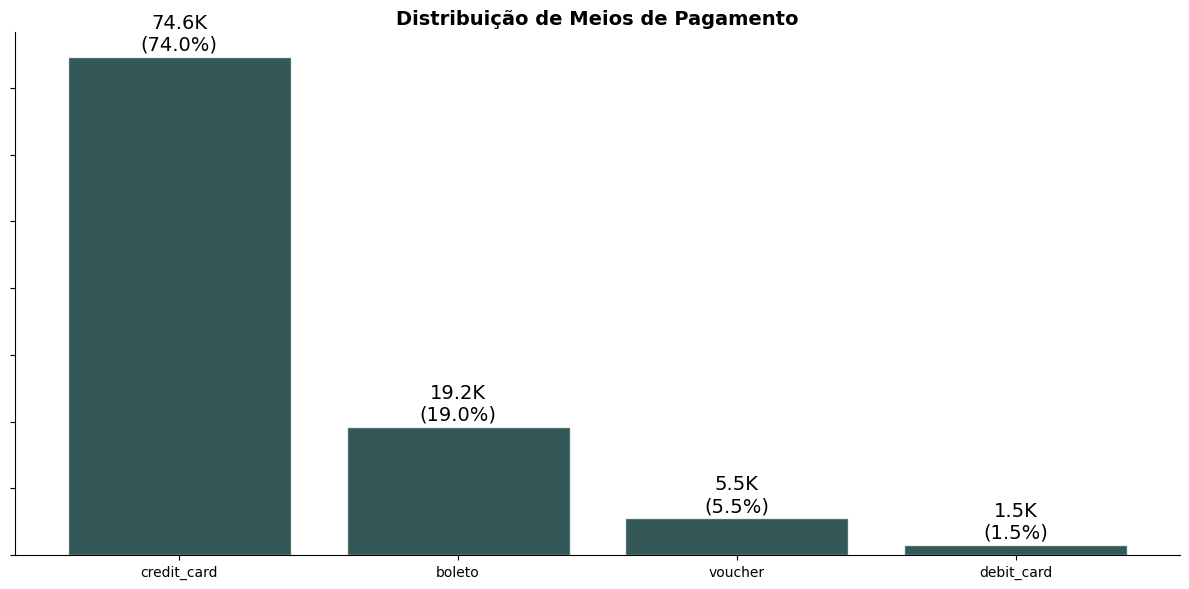

In [ ]:
# GRÁFICO 23: DISTRIBUIÇÃO DE MEIOS DE PAGAMENTO
print("\n📊 Gerando: Distribuição de Meios de Pagamento")

payment_dist = payments_orders['payment_type'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(payment_dist.index, payment_dist.values, color=COR_PRINCIPAL, alpha=0.8, edgecolor='white')

for bar in bars:
    height = bar.get_height()
    pct = height / payment_dist.sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2., height + 500,
            f'{fmt_compacto(height)}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=14, color='black')

ax.set_yticklabels([])
ax.set_title('Distribuição de Meios de Pagamento', fontsize=14, fontweight='bold', color='black')
estilo_limpo(ax)
plt.tight_layout()
plt.savefig('grafico_23_meios_pagamento.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


📊 Gerando: Valor Médio por Meio de Pagamento


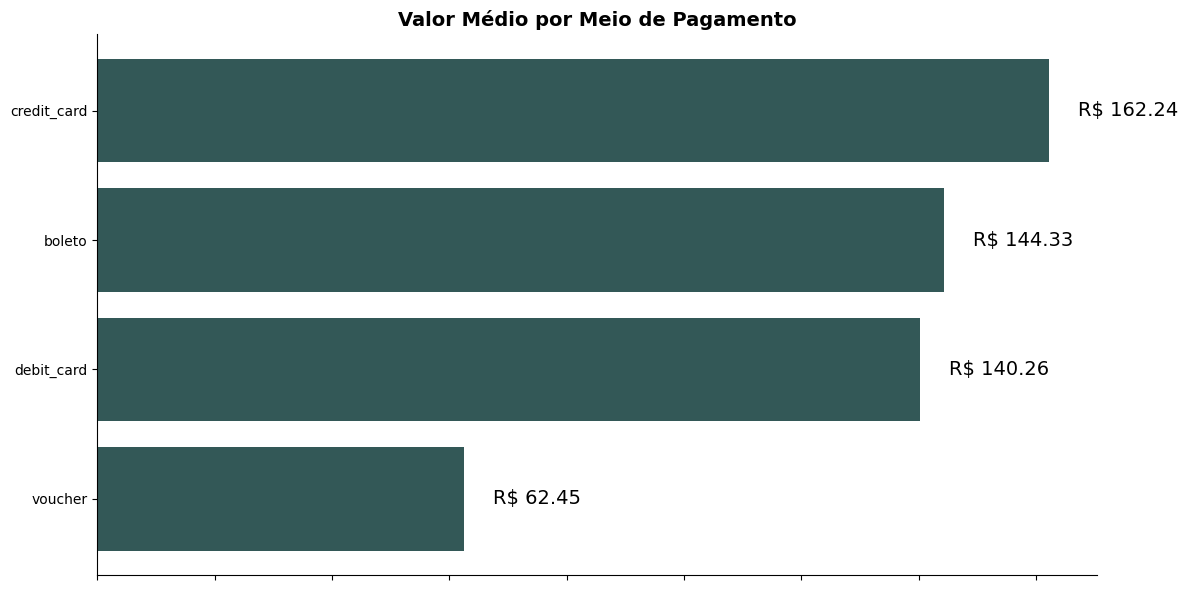

In [ ]:
# GRÁFICO 24: VALOR MÉDIO POR MEIO DE PAGAMENTO
print("\n📊 Gerando: Valor Médio por Meio de Pagamento")

payment_avg = payments_orders.groupby('payment_type')['payment_value'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(payment_avg.index, payment_avg.values, color=COR_PRINCIPAL, alpha=0.8)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 5, bar.get_y() + bar.get_height()/2,
            f'R$ {width:.2f}', va='center', fontsize=14, color='black')

ax.set_xticklabels([])
ax.set_title('Valor Médio por Meio de Pagamento', fontsize=14, fontweight='bold', color='black')
estilo_limpo(ax)
plt.tight_layout()
plt.savefig('grafico_24_valor_medio_pagamento.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


📊 Gerando: Distribuição de Número de Parcelas


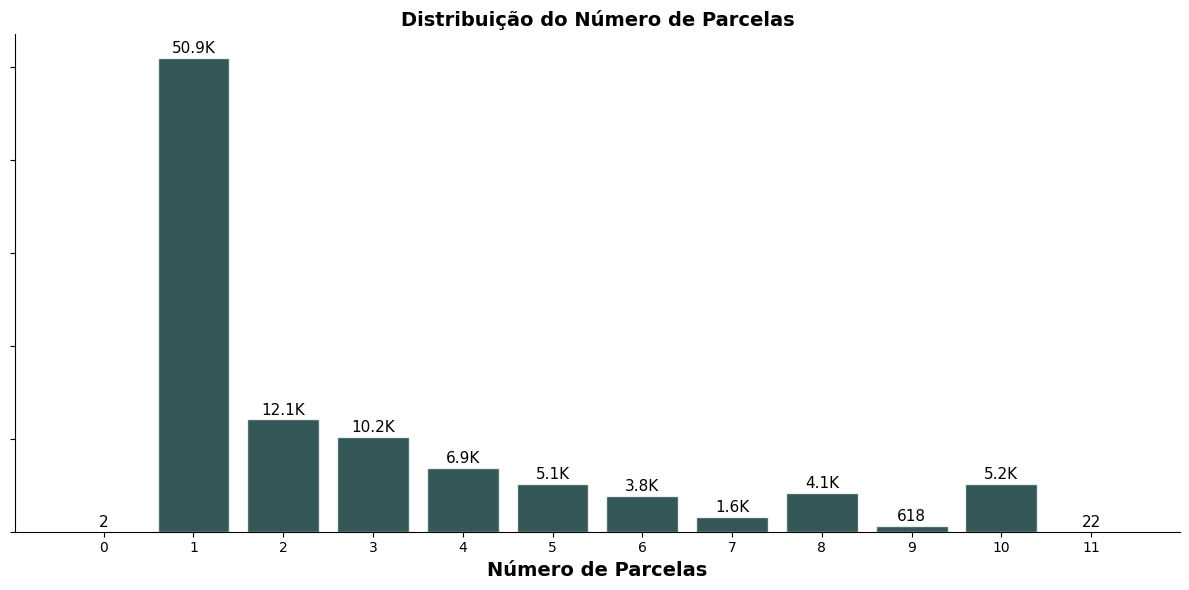

In [ ]:
# GRÁFICO 25: DISTRIBUIÇÃO DE PARCELAS
print("\n📊 Gerando: Distribuição de Número de Parcelas")

installments_dist = payments_orders['payment_installments'].value_counts().sort_index()
installments_top = installments_dist.head(12)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(installments_top.index.astype(str), installments_top.values,
              color=COR_PRINCIPAL, alpha=0.8, edgecolor='white')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 200,
            fmt_compacto(height), ha='center', va='bottom', fontsize=11, color='black')

ax.set_xlabel('Número de Parcelas', fontsize=14, fontweight='bold')
ax.set_yticklabels([])
ax.set_title('Distribuição do Número de Parcelas', fontsize=14, fontweight='bold', color='black')
estilo_limpo(ax)
plt.tight_layout()
plt.savefig('grafico_25_distribuicao_parcelas.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


📊 Gerando: Parcelamento Médio por Tipo de Pagamento


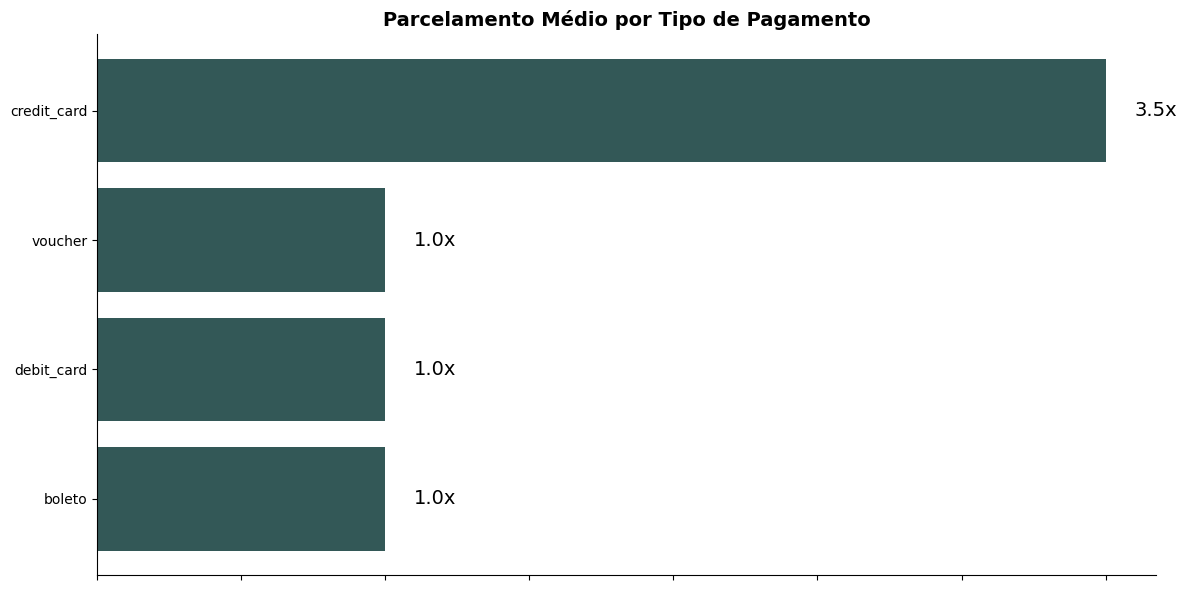

In [ ]:
# GRÁFICO 26: PARCELAMENTO MÉDIO POR TIPO DE PAGAMENTO
print("\n📊 Gerando: Parcelamento Médio por Tipo de Pagamento")

installments_by_type = payments_orders.groupby('payment_type')['payment_installments'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(installments_by_type.index, installments_by_type.values, color=COR_PRINCIPAL, alpha=0.8)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.1, bar.get_y() + bar.get_height()/2,
            f'{width:.1f}x', va='center', fontsize=14, color='black')

ax.set_xticklabels([])
ax.set_title('Parcelamento Médio por Tipo de Pagamento', fontsize=14, fontweight='bold', color='black')
estilo_limpo(ax)
plt.tight_layout()
plt.savefig('grafico_26_parcelamento_tipo.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


📊 Gerando: Distribuição de Segmentos RFM


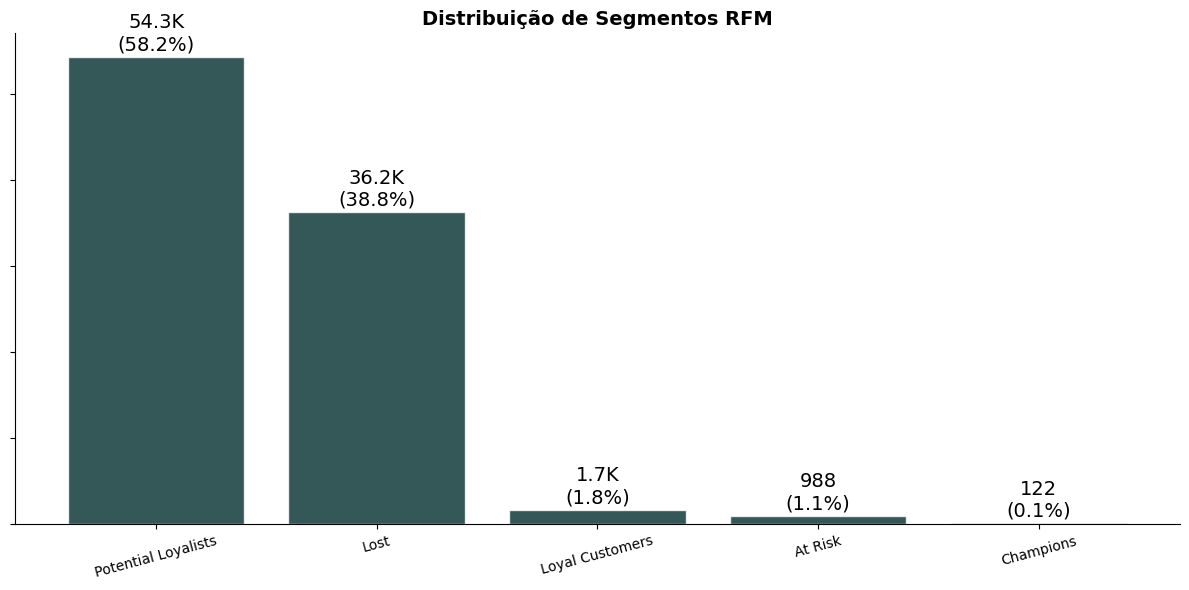

In [ ]:
# GRÁFICO 27: DISTRIBUIÇÃO DE SEGMENTOS RFM
print("\n📊 Gerando: Distribuição de Segmentos RFM")

segment_dist = rfm['segmento'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(segment_dist.index, segment_dist.values, color=COR_PRINCIPAL, alpha=0.8, edgecolor='white')

for bar in bars:
    height = bar.get_height()
    pct = height / segment_dist.sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2., height + 300,
            f'{fmt_compacto(height)}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=14, color='black')

ax.set_yticklabels([])
ax.tick_params(axis='x', rotation=15)
ax.set_title('Distribuição de Segmentos RFM', fontsize=14, fontweight='bold', color='black')
estilo_limpo(ax)
plt.tight_layout()
plt.savefig('grafico_27_segmentos_rfm.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


📊 Gerando: Receita Total por Segmento RFM


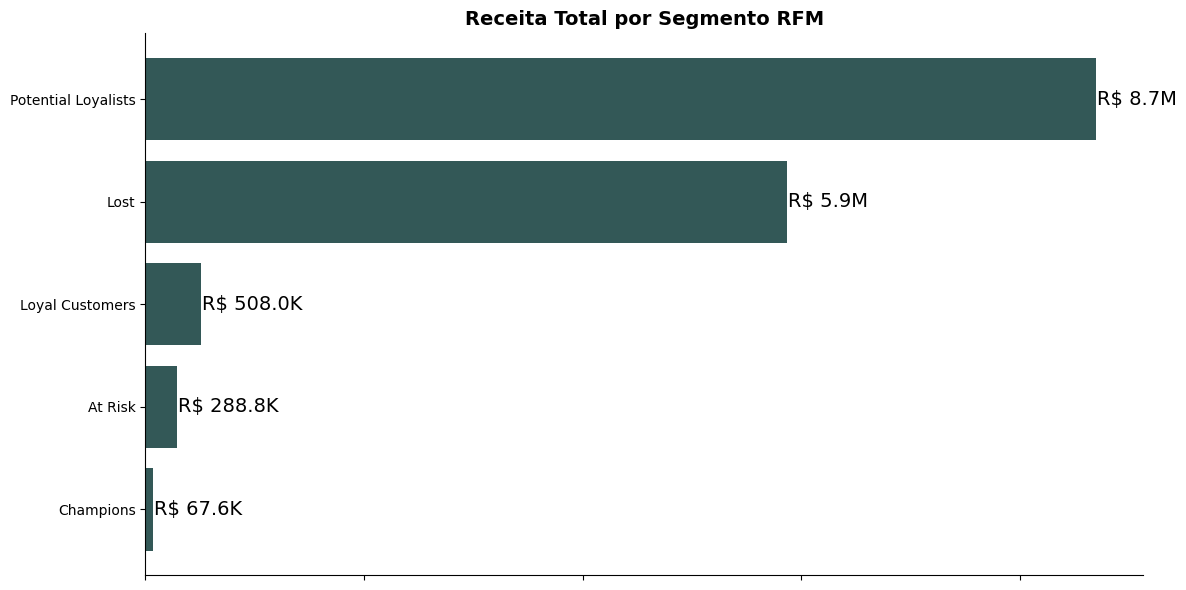

In [ ]:
# GRÁFICO 28: RECEITA POR SEGMENTO RFM
print("\n📊 Gerando: Receita Total por Segmento RFM")

segment_revenue = rfm.groupby('segmento')['monetizacao'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(segment_revenue.index, segment_revenue.values, color=COR_PRINCIPAL, alpha=0.8)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 10000, bar.get_y() + bar.get_height()/2,
            fmt_compacto_reais(width), va='center', fontsize=14, color='black')

ax.set_xticklabels([])
ax.set_title('Receita Total por Segmento RFM', fontsize=14, fontweight='bold', color='black')
estilo_limpo(ax)
plt.tight_layout()
plt.savefig('grafico_28_receita_segmento_rfm.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


📊 Gerando: Distribuição de Recência


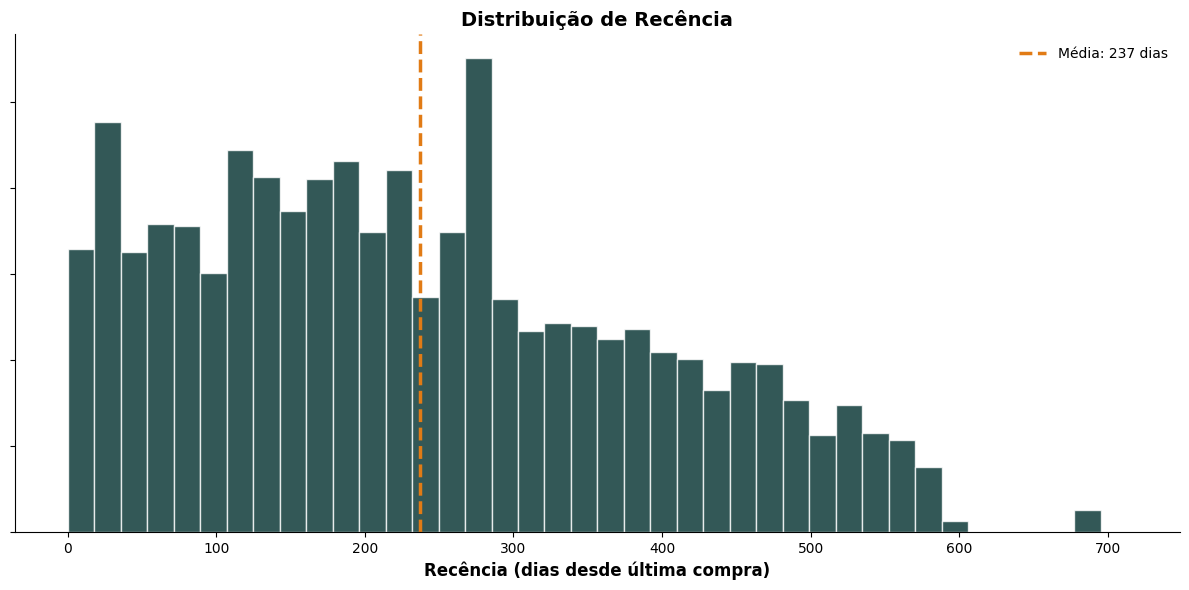

In [ ]:
# GRÁFICO 29: DISTRIBUIÇÃO DE RECÊNCIA
print("\n📊 Gerando: Distribuição de Recência")

fig, ax = plt.subplots(figsize=(12, 6))

data = rfm['recencia']
n, bins, patches = ax.hist(data, bins=40, color=COR_PRINCIPAL, alpha=0.8, edgecolor='white')

media = data.mean()
ax.axvline(media, color=COR_DESTAQUE, linestyle='--', linewidth=2.5,
           label=f'Média: {media:.0f} dias')

ax.set_xlabel('Recência (dias desde última compra)', fontsize=12, fontweight='bold')
ax.set_yticklabels([])
ax.set_title('Distribuição de Recência', fontsize=14, fontweight='bold', color='black')
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
estilo_limpo(ax)
plt.tight_layout()
plt.savefig('grafico_29_distribuicao_recencia.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


📊 Gerando: Taxa de Recompra


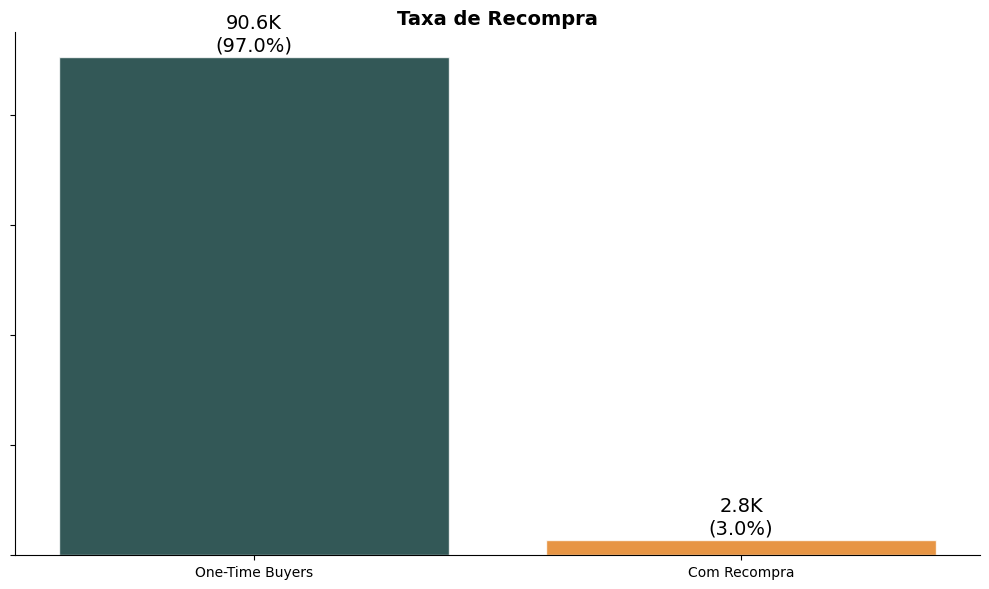

In [ ]:
# GRÁFICO 30: TAXA DE RECOMPRA
print("\n📊 Gerando: Taxa de Recompra")

clientes_com_recompra = (rfm['frequencia'] > 1).sum()
clientes_sem_recompra = len(rfm) - clientes_com_recompra

fig, ax = plt.subplots(figsize=(10, 6))

dados = [clientes_sem_recompra, clientes_com_recompra]
labels = ['One-Time Buyers', 'Com Recompra']

bars = ax.bar(labels, dados, color=[COR_PRINCIPAL, COR_DESTAQUE], alpha=0.8, edgecolor='white')

for bar in bars:
    height = bar.get_height()
    pct = height / sum(dados) * 100
    ax.text(bar.get_x() + bar.get_width()/2., height + 500,
            f'{fmt_compacto(height)}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=14, color='black')

ax.set_yticklabels([])
ax.set_title('Taxa de Recompra', fontsize=14, fontweight='bold', color='black')
estilo_limpo(ax)
plt.tight_layout()
plt.savefig('grafico_30_taxa_recompra.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


📊 Gerando: Distribuição de Frequência de Compra


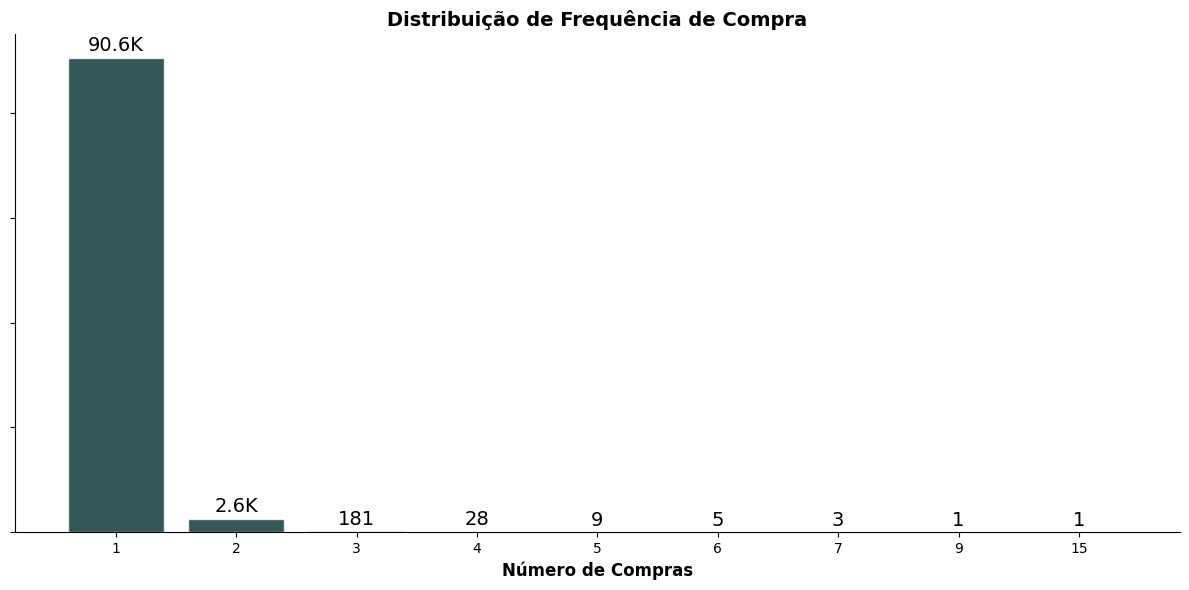

In [ ]:
# GRÁFICO 31: DISTRIBUIÇÃO DE FREQUÊNCIA DE COMPRA
print("\n📊 Gerando: Distribuição de Frequência de Compra")

freq_dist = rfm['frequencia'].value_counts().sort_index().head(10)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(freq_dist.index.astype(str), freq_dist.values, color=COR_PRINCIPAL, alpha=0.8, edgecolor='white')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 500,
            fmt_compacto(height), ha='center', va='bottom', fontsize=14, color='black')

ax.set_xlabel('Número de Compras', fontsize=12, fontweight='bold')
ax.set_yticklabels([])
ax.set_title('Distribuição de Frequência de Compra', fontsize=14, fontweight='bold', color='black')
estilo_limpo(ax)
plt.tight_layout()
plt.savefig('grafico_31_frequencia_compra.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()